In [1]:
# ── Installing all required libraries
# This installs every package we need for data download, modelling, and visualisation
!pip install yfinance pandas numpy scikit-learn tensorflow statsmodels pmdarima matplotlib seaborn pandas-datareader fredapi

# ── Standard data handling 
import pandas as pd          # tables and data manipulation
import numpy as np           # fast numerical operations on arrays

# ── Data download libraries 
import yfinance as yf        # downloads market prices from Yahoo Finance for free
import pandas_datareader.data as web  # downloads macro data from FRED (Federal Reserve)

# ── Scaling and evaluation tools 
from sklearn.preprocessing import MinMaxScaler           # scales values to 0-to-1 range
from sklearn.metrics import mean_squared_error, mean_absolute_error  # error metrics

# ── Deep learning framework 
from tensorflow.keras.models import Sequential           # builds layers one after another
from tensorflow.keras.layers import LSTM, Dense, Dropout # LSTM memory, output, regularisation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # training controls

# ── Statistical modelling 
from statsmodels.tsa.statespace.sarimax import SARIMAX  # rolling ARIMA forecasting
from pmdarima import auto_arima                          # automatic ARIMA order selection

# ── Visualisation 
import matplotlib.pyplot as plt   # base plotting library
import seaborn as sns             # cleaner chart styling on top of matplotlib

# ── Utility 
import warnings
warnings.filterwarnings("ignore")  # suppress non-critical output to keep notebook clean

# ── Set random seeds for reproducibility 
import tensorflow as tf
tf.random.set_seed(42)    # makes TensorFlow operations reproducible
np.random.seed(42)        # makes NumPy random operations reproducible

# ── Confirm everything loaded correctly 
print("All libraries imported successfully.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All libraries imported successfully.


In [2]:
# ── Defining the date range for the entire study 
START_DATE = "2010-01-01"
END_DATE   = "2025-04-30"
# We extend to April 2025 to align with the SARB data specified in the project brief

# ── Downloading the USD/ZAR daily closing rate from Yahoo Finance 
# ZAR=X is the Yahoo Finance ticker for the US Dollar vs South African Rand spot rate
print("Downloading USD/ZAR exchange rate...")
usdzar_raw = yf.download("ZAR=X", start=START_DATE, end=END_DATE)

# ── Keeping only the closing price and rename the column clearly 
# The closing price is the standard reference price used in FX time series analysis
usdzar = usdzar_raw[["Close"]].copy()
usdzar.columns = ["USDZAR"]

# ── Droping rows where the closing price is missing 
# Yahoo Finance returns NaN for weekends and public holidays where no trading occurs
usdzar.dropna(inplace=True)

# ── Confirming the download was successful 
print(f"USD/ZAR shape    : {usdzar.shape}")
print(f"Date range       : {usdzar.index.min().date()} to {usdzar.index.max().date()}")
print(f"\nFirst 3 rows:")
print(usdzar.head(3))
print(f"\nLast 3 rows:")
print(usdzar.tail(3))

[*********************100%***********************]  1 of 1 completed

USD/ZAR shape    : (3988, 1)
Date range       : 2010-01-01 to 2025-04-29

First 3 rows:
            USDZAR
Date              
2010-01-01  7.3402
2010-01-04  7.2649
2010-01-05  7.3019

Last 3 rows:
               USDZAR
Date                 
2025-04-25  18.749310
2025-04-28  18.682489
2025-04-29  18.494499


In [3]:
# ── Defining the commodity tickers on Yahoo Finance 
# Gold and platinum are South Africa's two largest export commodities
# Brent crude oil drives global risk sentiment and energy costs in South Africa
commodity_tickers = {
    "Gold"     : "GC=F",   # Gold futures price in USD per troy ounce
    "Platinum" : "PL=F",   # Platinum futures price in USD per troy ounce
    "Oil_Brent": "BZ=F",   # Brent crude oil futures price in USD per barrel
}

# ── Downloading each commodity separately and combining into one DataFrame 
# We download separately because some tickers may have different trading calendars
commodity_frames = []

for name, ticker in commodity_tickers.items():
    print(f"Downloading {name} ({ticker})...")
    raw = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    # Extract the closing price and rename the column to the commodity name
    col = raw[["Close"]].copy()
    col.columns = [name]
    commodity_frames.append(col)

# ── Merging all commodity price series on the date index 
# outer join keeps all dates; we will forward-fill gaps afterwards
commodities = pd.concat(commodity_frames, axis=1, join="outer")

# ── Forward-filling missing values caused by different trading calendars 
# If platinum did not trade on a day that gold did, carry the last known price forward
commodities.ffill(inplace=True)

# ── Droping any remaining rows where all values are still NaN 
commodities.dropna(inplace=True)

# ── Confirming the download 
print(f"\nCommodities shape : {commodities.shape}")
print(f"Date range        : {commodities.index.min().date()} to {commodities.index.max().date()}")
print(f"\nFirst 3 rows:")
print(commodities.head(3))
print(f"\nMissing values per column:")
print(commodities.isnull().sum())


Commodities shape : (3854, 3)
Date range        : 2010-01-04 to 2025-04-29

First 3 rows:
                   Gold     Platinum  Oil_Brent
Date                                           
2010-01-04  1117.699951  1517.300049  80.120003
2010-01-05  1118.099976  1530.800049  80.589996
2010-01-06  1135.900024  1552.199951  81.889999

Missing values per column:
Gold         0
Platinum     0
Oil_Brent    0
dtype: int64


In [4]:
# ── Downloading the US Federal Funds Rate from FRED 
# FRED is the Federal Reserve Economic Data database maintained by the St Louis Fed
# The Fed Funds rate is the benchmark US short-term interest rate
# It is freely available via pandas_datareader without an API key for this series
print("Downloading US Federal Funds Rate from FRED...")
fed_funds = web.DataReader("FEDFUNDS", "fred", START_DATE, END_DATE)
# FEDFUNDS is a monthly series: rate is reported as the last value of each month
fed_funds.columns = ["Fed_Funds_Rate"]
# The rate is in percent per annum (e.g. 5.25 means 5.25% per year)

# ── Downloading the SARB Repo Rate from FRED 
# INTDSRZAM193N is the FRED code for the South African Reserve Bank repo rate
# This is also a monthly series reported as percent per annum
print("Downloading SARB Repo Rate from FRED...")
sarb_repo = web.DataReader("INTDSRZAM193N", "fred", START_DATE, END_DATE)
sarb_repo.columns = ["SARB_Repo_Rate"]

# ── Computing the interest rate differential 
# The differential = SARB Repo Rate minus Fed Funds Rate
# A positive differential means SA rates are higher than US rates
# Higher SA rates typically attract capital inflows, strengthening the ZAR
rate_diff = pd.concat([fed_funds, sarb_repo], axis=1)
rate_diff["Rate_Differential"] = rate_diff["SARB_Repo_Rate"] - rate_diff["Fed_Funds_Rate"]
# We keep all three columns: Fed rate, SARB rate, and the spread between them

# ── Resampling from monthly to daily frequency 
# Our USD/ZAR data is daily, so we must convert the monthly rates to daily
# We forward-fill: hold the last known monthly rate constant until the next update
rate_diff_daily = rate_diff.resample("D").ffill()
# resample("D") creates a row for every calendar day
# ffill() fills weekends and mid-month days with the most recent monthly value

# ── Confirming the download 
print(f"\nRate differential shape : {rate_diff_daily.shape}")
print(f"Date range              : {rate_diff_daily.index.min().date()} to {rate_diff_daily.index.max().date()}")
print(f"\nFirst 3 rows:")
print(rate_diff_daily.head(3))
print(f"\nLatest rates:")
print(rate_diff_daily.tail(3))


Rate differential shape : (5570, 3)
Date range              : 2010-01-01 to 2025-04-01

First 3 rows:
            Fed_Funds_Rate  SARB_Repo_Rate  Rate_Differential
DATE                                                         
2010-01-01            0.11             7.0               6.89
2010-01-02            0.11             7.0               6.89
2010-01-03            0.11             7.0               6.89

Latest rates:
            Fed_Funds_Rate  SARB_Repo_Rate  Rate_Differential
DATE                                                         
2025-03-30            4.33             NaN                NaN
2025-03-31            4.33             NaN                NaN
2025-04-01            4.33             NaN                NaN


In [5]:
# ── Downloading South African economic indicators from FRED 
# These are monthly or quarterly macro series that influence the ZAR

print("Downloading SA economic indicators from FRED...")

# South Africa Consumer Price Index (inflation proxy)
# ZAFCPIALLMINMEI: monthly CPI for South Africa, all items
sa_cpi = web.DataReader("ZAFCPIALLMINMEI", "fred", START_DATE, END_DATE)
sa_cpi.columns = ["SA_CPI"]

# South Africa trade balance is not directly on FRED as a clean daily series
# We use the USD/ZAR real effective exchange rate as a proxy for external balance pressure
# RBUSBIS: BIS Real Broad Effective Exchange Rate for South Africa (monthly)
try:
    sa_reer = web.DataReader("RBUSBIS", "fred", START_DATE, END_DATE)
    sa_reer.columns = ["SA_REER"]
    reer_available = True
    print("SA REER downloaded successfully.")
except Exception:
    # If the REER series is unavailable, we skip it and note this
    reer_available = False
    print("SA REER not available on FRED. Skipping.")

# US GDP growth (quarterly) as a proxy for global demand conditions
# A1USGDPD: US Real GDP, percent change from preceding period
try:
    us_gdp = web.DataReader("A191RL1Q225SBEA", "fred", START_DATE, END_DATE)
    us_gdp.columns = ["US_GDP_Growth"]
    gdp_available = True
    print("US GDP Growth downloaded successfully.")
except Exception:
    gdp_available = False
    print("US GDP data not available. Skipping.")

# ── Resampling all monthly/quarterly series to daily frequency 
sa_cpi_daily = sa_cpi.resample("D").ffill()
# Forward-filling converts monthly CPI readings to daily by holding the value constant

if reer_available:
    sa_reer_daily = sa_reer.resample("D").ffill()
if gdp_available:
    us_gdp_daily = us_gdp.resample("D").ffill()

# ── Merging all data sources into one master DataFrame 
# Starting with the USD/ZAR rate as the base (it determines our date index)
print("\nMerging all data sources...")
df = usdzar.copy()
# df currently has one column: USDZAR

# Merging commodity prices (daily data, inner join on trading days)
df = df.join(commodities, how="left")
# left join keeps all USD/ZAR trading days and fills commodity gaps

# Merging interest rate differential (now daily after resample)
df = df.join(rate_diff_daily[["Fed_Funds_Rate", "SARB_Repo_Rate", "Rate_Differential"]], how="left")

# Merging SA CPI
df = df.join(sa_cpi_daily, how="left")

# Merging REER if available
if reer_available:
    df = df.join(sa_reer_daily, how="left")

# Merging US GDP if available
if gdp_available:
    df = df.join(us_gdp_daily, how="left")

# ── Forward-filling any remaining gaps caused by calendar mismatches 
# Some macro series may have gaps around holidays or reporting lags
df.ffill(inplace=True)

# ── Droping any rows that still have missing values after forward-filling 
# This typically removes only the very first few rows before macro data starts
rows_before = len(df)
df.dropna(inplace=True)
rows_after  = len(df)
print(f"Rows dropped due to missing values: {rows_before - rows_after}")

# ── Printing the final master dataset summary 
print(f"\nMaster dataset shape : {df.shape}")
print(f"Date range           : {df.index.min().date()} to {df.index.max().date()}")
print(f"\nColumns in dataset:")
for col in df.columns:
    print(f"  {col}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nMissing values after merge:")
print(df.isnull().sum())

SA REER downloaded successfully.
US GDP Growth downloaded successfully.

Merging all data sources...
Rows dropped due to missing values: 1

Master dataset shape : (3987, 10)
Date range           : 2010-01-04 to 2025-04-29

Columns in dataset:
  USDZAR
  Gold
  Platinum
  Oil_Brent
  Fed_Funds_Rate
  SARB_Repo_Rate
  Rate_Differential
  SA_CPI
  SA_REER
  US_GDP_Growth

First 3 rows:
            USDZAR         Gold     Platinum  Oil_Brent  Fed_Funds_Rate  \
Date                                                                      
2010-01-04  7.2649  1117.699951  1517.300049  80.120003            0.11   
2010-01-05  7.3019  1118.099976  1530.800049  80.589996            0.11   
2010-01-06  7.3022  1135.900024  1552.199951  81.889999            0.11   

            SARB_Repo_Rate  Rate_Differential   SA_CPI  SA_REER  US_GDP_Growth  
Date                                                                            
2010-01-04             7.0               6.89  75.3046    84.36            1

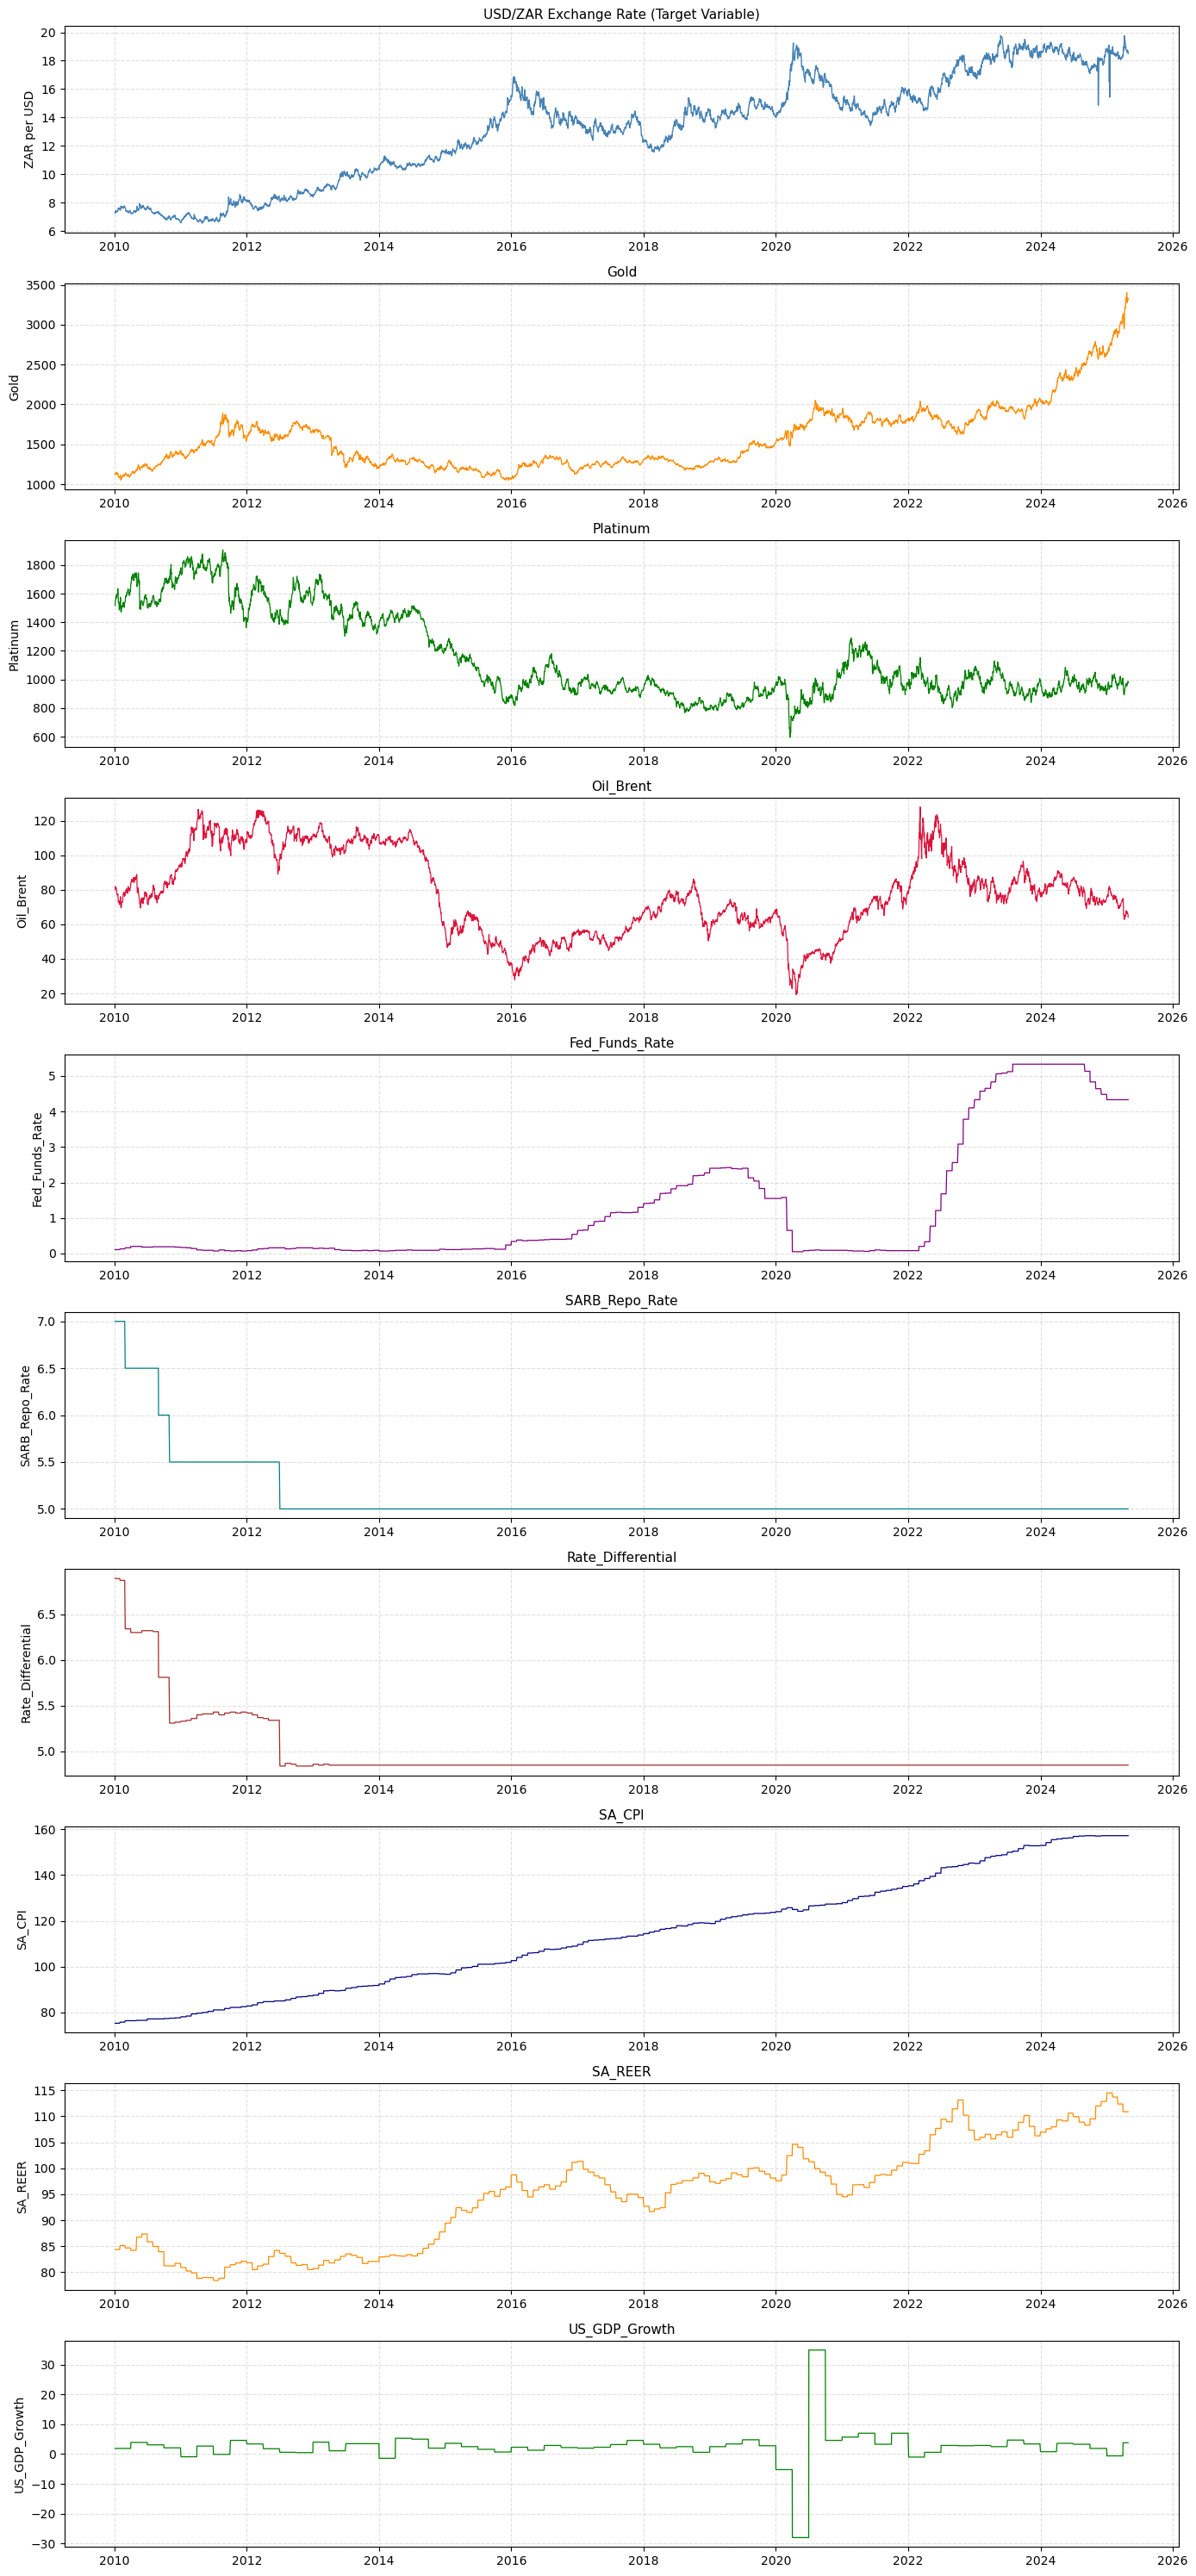

Descriptive Statistics for All Variables:
          USDZAR       Gold   Platinum  Oil_Brent  Fed_Funds_Rate  \
count  3987.0000  3987.0000  3987.0000  3987.0000       3987.0000   
mean     13.1798  1573.8931  1152.9357    78.2201          1.2953   
std       3.7107   401.1927   301.9839    23.9122          1.7531   
min       6.5630  1050.8000   595.9000    19.3300          0.0500   
25%      10.2081  1263.6500   927.3000    59.9500          0.0950   
50%      13.8312  1471.8000  1006.2000    76.4900          0.2000   
75%      15.7746  1798.9000  1435.1500   100.7600          1.9100   
max      19.7745  3400.8000  1905.7000   127.9800          5.3300   

       SARB_Repo_Rate  Rate_Differential     SA_CPI    SA_REER  US_GDP_Growth  
count       3987.0000          3987.0000  3987.0000  3987.0000      3987.0000  
mean           5.1349             4.9872   113.6833    94.7665         2.5583  
std            0.3667             0.3668    24.8137     9.8924         6.0447  
min            5

In [6]:
# ── Getting the list of all feature columns excluding the target variable 
# USDZAR is our target (what we want to predict)
# Everything else is a feature (what we use to make predictions)
feature_cols = [col for col in df.columns if col != "USDZAR"]
# listing comprehension loops through all column names and keeps those that are not USDZAR

# ── Plot the USD/ZAR rate first as the target variable 
fig, axes = plt.subplots(nrows=len(feature_cols) + 1, ncols=1,
                         figsize=(14, 3 * (len(feature_cols) + 1)))
# subplots creates a grid of charts: one row per variable, one column
# figsize scales the height based on how many features we have

# Plot the target: USD/ZAR closing price
axes[0].plot(df.index, df["USDZAR"], color="steelblue", linewidth=1.0)
axes[0].set_title("USD/ZAR Exchange Rate (Target Variable)", fontsize=11)
axes[0].set_ylabel("ZAR per USD")
axes[0].grid(True, linestyle="--", alpha=0.4)

# ── Plotting each feature variable in its own subplot 
colors = ["darkorange", "green", "crimson", "purple", "teal", "brown", "navy"]
# We define a list of colours so each feature gets a visually distinct line

for i, col in enumerate(feature_cols):
    ax = axes[i + 1]
    # i + 1 because axes[0] is already used for USDZAR
    ax.plot(df.index, df[col], color=colors[i % len(colors)], linewidth=0.9)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel(col)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
# tight_layout automatically adjusts spacing between subplots so nothing overlaps
plt.show()

# ── Print descriptive statistics for all columns ──────────────────────────────────
print("Descriptive Statistics for All Variables:")
print(df.describe().round(4))

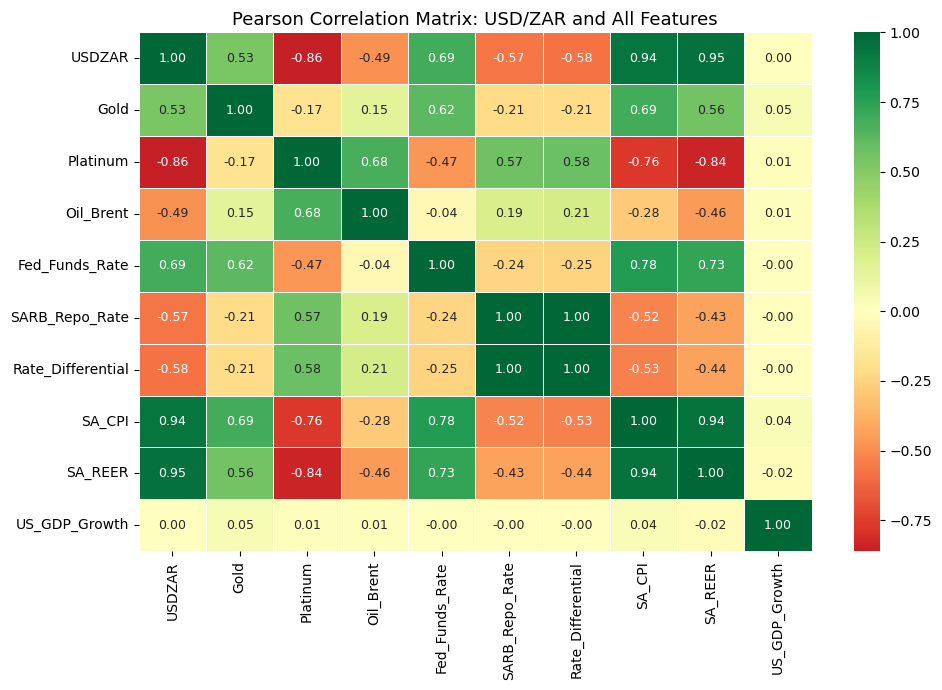

Correlation with USD/ZAR (sorted by absolute value):
  SA_REER                   : +0.9503
  SA_CPI                    : +0.9414
  Platinum                  : -0.8607
  Fed_Funds_Rate            : +0.6897
  Rate_Differential         : -0.5800
  SARB_Repo_Rate            : -0.5712
  Gold                      : +0.5309
  Oil_Brent                 : -0.4884
  US_GDP_Growth             : +0.0024

Interpretation:
Correlations above |0.5| suggest a meaningful linear relationship with USD/ZAR.
Note: correlation measures linear relationships only.
LSTM can also capture nonlinear dependencies that correlation does not detect.


In [7]:
# ── Computing the correlation matrix across all variables 
# Pearson correlation measures the linear relationship between each pair of variables
# Values range from -1 (perfect negative) to +1 (perfect positive)
# Values near 0 indicate no linear relationship
corr_matrix = df.corr()
# df.corr() computes pairwise Pearson correlations for all numeric columns

# ── Plotting the correlation heatmap 
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,          # annot=True prints the correlation value inside each cell
    fmt=".2f",           # fmt=".2f" rounds values to 2 decimal places
    cmap="RdYlGn",       # RdYlGn: red for negative, yellow for near-zero, green for positive
    center=0,            # center=0 makes zero correlation appear as yellow (neutral)
    linewidths=0.5,      # linewidths adds thin lines between cells for readability
    annot_kws={"size": 9}# annot_kws controls the font size of the numbers inside cells
)
plt.title("Pearson Correlation Matrix: USD/ZAR and All Features", fontsize=13)
plt.tight_layout()
plt.show()

# ── Printting the correlations with USDZAR specifically, sorted by strength 
print("Correlation with USD/ZAR (sorted by absolute value):")
usdzar_corr = corr_matrix["USDZAR"].drop("USDZAR")
# drop("USDZAR") removes the self-correlation of 1.0 which is not meaningful
usdzar_corr_sorted = usdzar_corr.abs().sort_values(ascending=False)
# abs() takes absolute values so we rank by strength regardless of direction
for col in usdzar_corr_sorted.index:
    print(f"  {col:<25} : {usdzar_corr[col]:+.4f}")
# The + in {:+.4f} forces the sign to always be shown (+ or -)

# ── Printing an interpretation note 
print("\nInterpretation:")
print("Correlations above |0.5| suggest a meaningful linear relationship with USD/ZAR.")
print("Note: correlation measures linear relationships only.")
print("LSTM can also capture nonlinear dependencies that correlation does not detect.")

REER change computed.
GDP change computed.

Dataset shape after transformations: (3986, 18)

All columns now in dataset:
  USDZAR
  Gold
  Platinum
  Oil_Brent
  Fed_Funds_Rate
  SARB_Repo_Rate
  Rate_Differential
  SA_CPI
  SA_REER
  US_GDP_Growth
  USDZAR_Return
  Gold_Return
  Platinum_Return
  Oil_Brent_Return
  Rate_Diff_Change
  CPI_Change
  REER_Change
  GDP_Change


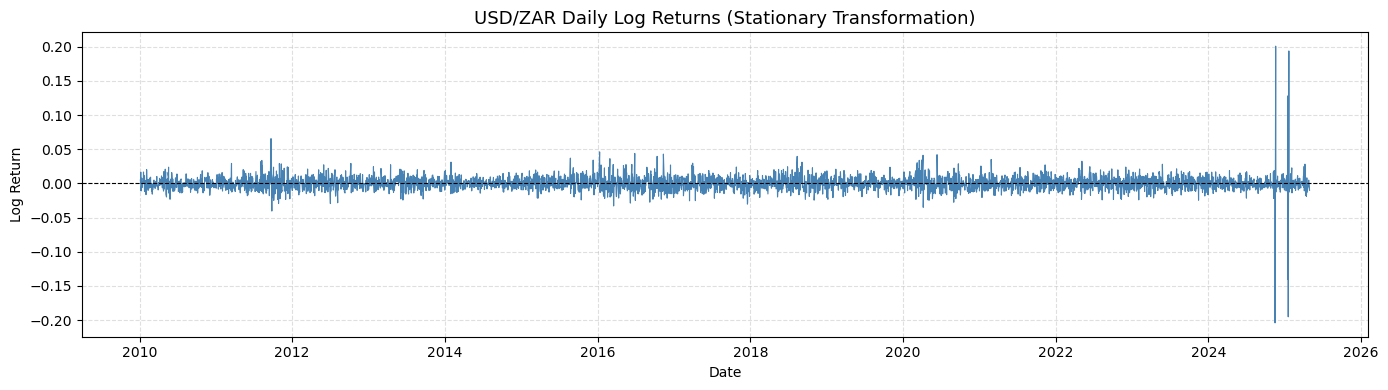

In [8]:
# ── Computing log returns for the USD/ZAR target variable 
# Log returns are used instead of raw prices because prices are non-stationary
# r_t = ln(P_t) - ln(P_{t-1}) removes the unit root and makes the series stationary
df["USDZAR_Return"] = np.log(df["USDZAR"] / df["USDZAR"].shift(1))
# shift(1) moves the series one day back so we are dividing today by yesterday

# ── Computing log returns for commodity prices 
# Commodity prices are also non-stationary and benefit from the same transformation
for col in ["Gold", "Platinum", "Oil_Brent"]:
    df[f"{col}_Return"] = np.log(df[col] / df[col].shift(1))
    # We create a new column for each commodity return

# ── Computing changes in interest rates 
# Interest rates are already in percent terms, so we take first differences
# A first difference removes the trend and gives us the change in rate each period
df["Rate_Diff_Change"] = df["Rate_Differential"].diff()
# diff() computes the day-to-day change: today's value minus yesterday's value

# ── Computing percentage change in CPI 
# CPI is a level series, so we take the month-on-month percentage change
df["CPI_Change"] = df["SA_CPI"].pct_change()
# pct_change() computes (today - yesterday) / yesterday, giving the percentage change

# ── Computing percentage change in REER if available 
if "SA_REER" in df.columns:
    df["REER_Change"] = df["SA_REER"].pct_change()
    print("REER change computed.")

# ── Computing percentage change in US GDP growth if available 
if "US_GDP_Growth" in df.columns:
    df["GDP_Change"] = df["US_GDP_Growth"].pct_change()
    print("GDP change computed.")

# ── Droping NaN rows created by the shift and diff operations 
# The first row of every shifted or differenced column will be NaN
df.dropna(inplace=True)

# ── Confirming the new columns were created correctly 
print(f"\nDataset shape after transformations: {df.shape}")
print(f"\nAll columns now in dataset:")
for col in df.columns:
    print(f"  {col}")

# ── Plotting the log returns of the target variable 
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["USDZAR_Return"], color="steelblue", linewidth=0.8)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("USD/ZAR Daily Log Returns (Stationary Transformation)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

REER_Change added to features.
GDP_Change added to features.

Final modelling dataset shape : (3986, 9)
Date range                    : 2010-01-05 to 2025-04-29
Number of features            : 8 input features + 1 target

Feature list:
  1. USDZAR_Return <-- TARGET
  2. Gold_Return
  3. Platinum_Return
  4. Oil_Brent_Return
  5. Rate_Differential
  6. Rate_Diff_Change
  7. CPI_Change
  8. REER_Change
  9. GDP_Change


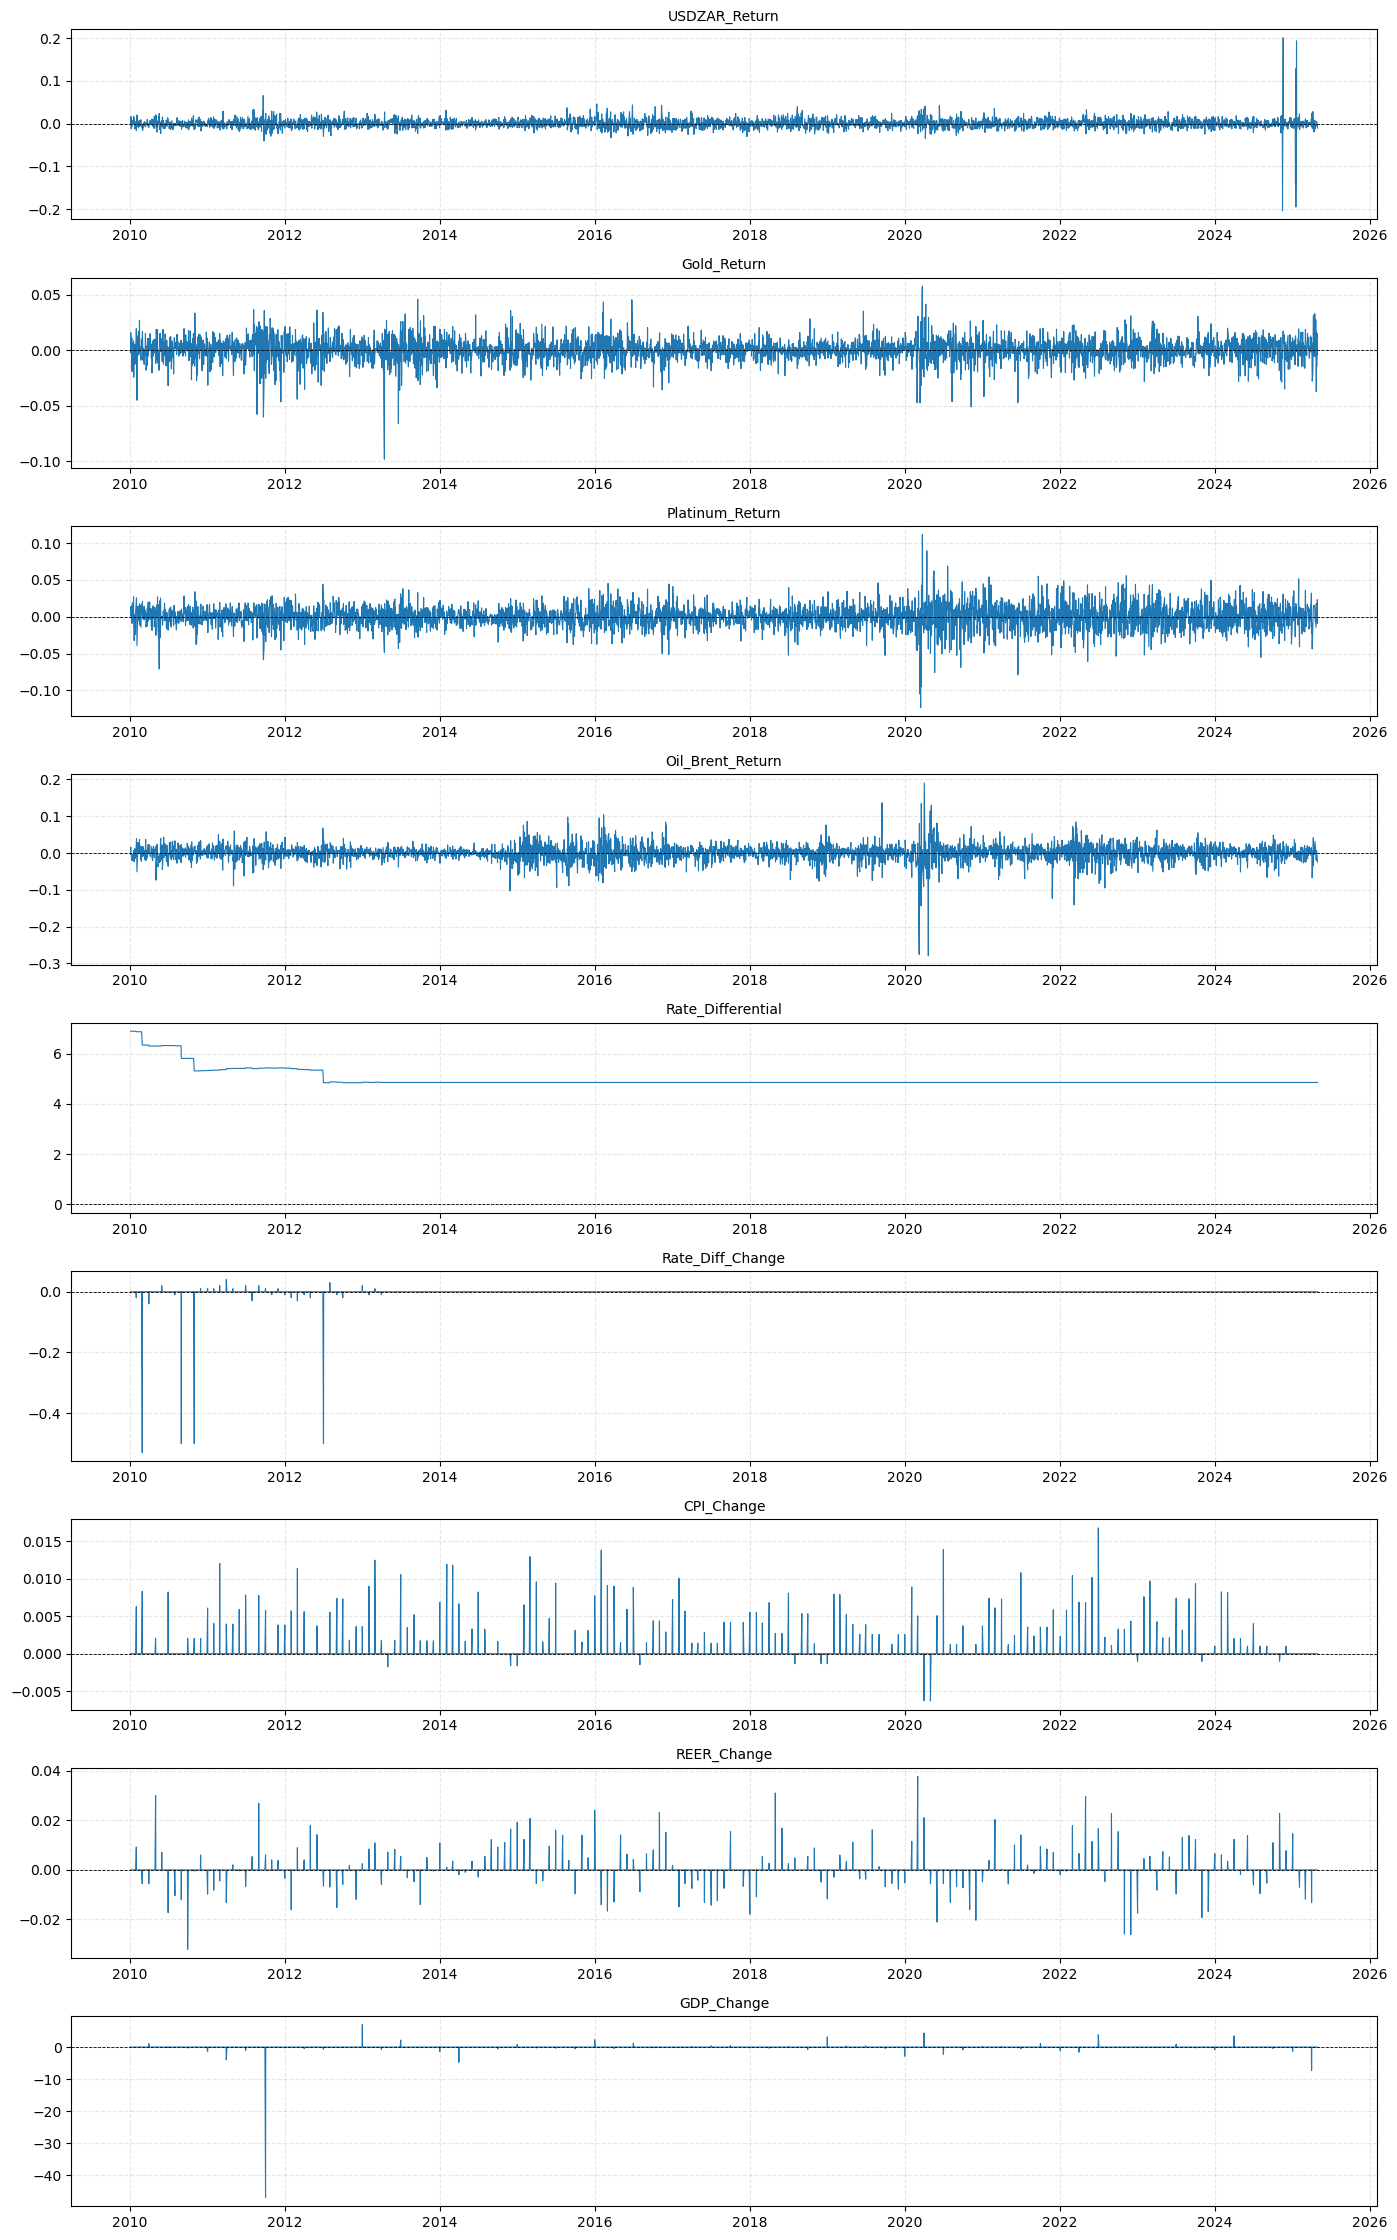

In [9]:
# ── Defining which columns to use as input features for the LSTM 
# We use stationary-transformed versions of all variables
# Using returns and changes instead of levels ensures the model learns from
# meaningful signals rather than spurious trending relationships

# Starting with the columns we know exist
selected_features = [
    "USDZAR_Return",      # log return of USD/ZAR: the primary signal
    "Gold_Return",        # log return of gold price: SA's largest export
    "Platinum_Return",    # log return of platinum price: SA's second major export
    "Oil_Brent_Return",   # log return of Brent crude: global risk and cost signal
    "Rate_Differential",  # SARB minus Fed Funds rate: carry trade driver
    "Rate_Diff_Change",   # day-to-day change in rate differential
    "CPI_Change",         # month-on-month SA inflation change
]

# ── Adding optional columns only if they exist in the dataset 
# Some series may have been unavailable from FRED during download
if "REER_Change" in df.columns:
    selected_features.append("REER_Change")
    print("REER_Change added to features.")

if "GDP_Change" in df.columns:
    selected_features.append("GDP_Change")
    print("GDP_Change added to features.")

# ── Building the modelling DataFrame with only the selected features 
model_df = df[selected_features].copy()
# We keep only the transformed feature columns for modelling
# The raw price levels (USDZAR, Gold, etc.) are stored in df for reference

# ── Drop any remaining NaN rows 
model_df.dropna(inplace=True)

# ── The target variable is the USD/ZAR log return 
# The model will predict whether the ZAR strengthens or weakens each day
TARGET = "USDZAR_Return"
# All other columns in model_df are the input features

# ── Printting the final modelling dataset summary 
print(f"\nFinal modelling dataset shape : {model_df.shape}")
print(f"Date range                    : {model_df.index.min().date()} to {model_df.index.max().date()}")
print(f"Number of features            : {len(selected_features) - 1} input features + 1 target")
print(f"\nFeature list:")
for i, col in enumerate(selected_features):
    tag = " <-- TARGET" if col == TARGET else ""
    print(f"  {i+1}. {col}{tag}")

# ── Plotting all selected features together to confirm they look stationary 
fig, axes = plt.subplots(len(selected_features), 1,
                         figsize=(14, 2.5 * len(selected_features)))
for i, col in enumerate(selected_features):
    axes[i].plot(model_df.index, model_df[col], linewidth=0.8)
    axes[i].axhline(0, color="black", linewidth=0.6, linestyle="--")
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ── Spliting the data into training and test sets (80/20 chronological split)
# We split chronologically: past data trains the model, recent data tests it
# We NEVER shuffle time series data as this would destroy the temporal ordering
split_index = int(len(model_df) * 0.80)
# 80% of rows go to training, the remaining 20% go to testing

train_df = model_df.iloc[:split_index].copy()
# iloc[:split_index] selects all rows from the start up to the split point
test_df  = model_df.iloc[split_index:].copy()
# iloc[split_index:] selects all rows from the split point to the end

# ── Printing split details 
print(f"Total observations   : {len(model_df)}")
print(f"Training observations: {len(train_df)}")
print(f"Test observations    : {len(test_df)}")
print(f"\nTraining period: {train_df.index.min().date()} to {train_df.index.max().date()}")
print(f"Test period    : {test_df.index.min().date()} to {test_df.index.max().date()}")

# ── Scaling all features to the 0-to-1 range using MinMaxScaler 
# CRITICAL: the scaler is FITTED on training data only
# Fitting on all data would leak future information into training (data leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
# MinMaxScaler: scaled = (value - min) / (max - min)
# feature_range=(0,1) means output is always between 0 and 1

train_scaled = scaler.fit_transform(train_df)
# fit_transform: learns the min and max from training data AND scales it in one step
# train_scaled is a 2D numpy array of shape (training_rows, num_features)

test_scaled = scaler.transform(test_df)
# transform only: applies the training min/max to the test data
# we do NOT refit the scaler on test data to avoid leakage

# ── Identifying the column index of the target variable 
# We need to know which column is USDZAR_Return so we can extract predictions later
target_col_index = model_df.columns.get_loc(TARGET)
# get_loc returns the integer position of the column named TARGET
print(f"\nTarget column '{TARGET}' is at index position: {target_col_index}")

# ── Confirming scaling worked correctly 
print(f"\nTraining scaled shape : {train_scaled.shape}")
print(f"Test scaled shape     : {test_scaled.shape}")
print(f"Training scaled min   : {train_scaled.min():.4f}")
print(f"Training scaled max   : {train_scaled.max():.4f}")
# Min and max of the training set should be exactly 0.0 and 1.0
print(f"Test scaled min       : {test_scaled.min():.4f}")
print(f"Test scaled max       : {test_scaled.max():.4f}")
# Test values may slightly exceed the 0-1 range if prices moved outside the training range

Total observations   : 3986
Training observations: 3188
Test observations    : 798

Training period: 2010-01-05 to 2022-04-04
Test period    : 2022-04-05 to 2025-04-29

Target column 'USDZAR_Return' is at index position: 0

Training scaled shape : (3188, 9)
Test scaled shape     : (798, 9)
Training scaled min   : 0.0000
Training scaled max   : 1.0000
Test scaled min       : -1.5442
Test scaled max       : 2.2767


In [11]:
# ── Defining a function to create sliding window sequences for multivariate input ───
# In the univariate version, each input was a 1D window of 30 past prices
# In the multivariate version, each input is a 2D window:
# rows = timesteps (30 days), columns = all features (returns, rates, CPI etc.)
# The model sees the full feature matrix for each of the past 30 days

def create_sequences_multivariate(data, target_col_idx, lookback):
    # data          : 2D scaled numpy array of shape (n_observations, n_features)
    # target_col_idx: integer index of the column we want to predict (USDZAR_Return)
    # lookback      : number of past days to include in each input window

    X = []   # X will store the input sequences (3D: samples x timesteps x features)
    y = []   # y will store the target values (next day's USDZAR_Return)

    for i in range(lookback, len(data)):
        # Grab the full feature matrix for the past 'lookback' days
        X.append(data[i - lookback:i, :])
        # data[i-lookback:i, :] selects all columns for the lookback window
        # This gives a 2D slice of shape (lookback, n_features)

        # The target is the USDZAR_Return value on day i (the day we are predicting)
        y.append(data[i, target_col_idx])
        # target_col_idx tells us which column holds the USDZAR_Return values

    return np.array(X), np.array(y)
    # np.array(X) produces shape (n_samples, lookback, n_features)
    # np.array(y) produces shape (n_samples,)

# ── Setting the lookback window 
LOOKBACK = 30
# 30 trading days is approximately 6 calendar weeks of market history
# The model will see the full feature matrix across these 30 days for each prediction

# ── Creating training sequences
X_train, y_train = create_sequences_multivariate(train_scaled, target_col_index, LOOKBACK)
# X_train: 3D array of shape (samples, 30, n_features)
# y_train: 1D array of shape (samples,) containing next-day USDZAR_Return values

# ── Creating test sequences 
X_test, y_test = create_sequences_multivariate(test_scaled, target_col_index, LOOKBACK)
# Same structure applied to the scaled test data

# ── Confirming the shapes are correct before building the model
n_features = X_train.shape[2]
# X_train.shape[2] gives the number of features (third dimension of the 3D array)

print(f"X_train shape : {X_train.shape}")
# Expected: (n_training_samples, 30, n_features)
print(f"y_train shape : {y_train.shape}")
# Expected: (n_training_samples,)
print(f"X_test shape  : {X_test.shape}")
# Expected: (n_test_samples, 30, n_features)
print(f"y_test shape  : {y_test.shape}")
# Expected: (n_test_samples,)
print(f"\nNumber of input features per timestep : {n_features}")
print(f"Lookback window                        : {LOOKBACK} trading days")
print(f"\nEach training sample is a ({LOOKBACK} x {n_features}) feature matrix.")
print("The model learns from ALL features simultaneously across the 30-day window.")

X_train shape : (3158, 30, 9)
y_train shape : (3158,)
X_test shape  : (768, 30, 9)
y_test shape  : (768,)

Number of input features per timestep : 9
Lookback window                        : 30 trading days

Each training sample is a (30 x 9) feature matrix.
The model learns from ALL features simultaneously across the 30-day window.


In [12]:
# ── Setting random seeds again to ensure the model build is reproducible
tf.random.set_seed(42)
np.random.seed(42)

# ── Building the stacked LSTM model 
# The architecture is the same as the univariate version
# The key difference is the input_shape: (LOOKBACK, n_features) instead of (LOOKBACK, 1)
# This tells the LSTM that each timestep contains n_features values, not just 1

model = Sequential()
# Sequential: layers are added one after the other in a straight line

# ── First LSTM layer: 128 units 
# We increase from 64 to 128 units compared to the univariate model
# More features = more complex input = more capacity needed to learn patterns
model.add(LSTM(
    units=128,
    # 128 memory cells in this layer to handle the richer multivariate input
    return_sequences=True,
    # return_sequences=True passes the full 30-step hidden state to the next LSTM layer
    input_shape=(LOOKBACK, n_features)
    # input_shape tells Keras: each sample has 30 timesteps and n_features per timestep
))

# ── First Dropout layer 
model.add(Dropout(0.2))
# Dropout(0.2) randomly silences 20% of neurons during each training step
# This prevents the model from memorising training sequences (overfitting)

# ── Second LSTM layer: 64 units 
model.add(LSTM(
    units=64,
    # 64 units in the second layer: funnel structure reduces complexity progressively
    return_sequences=False
    # return_sequences=False: only the final timestep's hidden state is passed forward
    # This is correct for the last LSTM layer before the Dense output
))

# ── Second Dropout layer 
model.add(Dropout(0.2))
# Another 20% dropout to continue regularising the deeper layer

# ── Output layer 
model.add(Dense(units=1))
# Dense(1): a single neuron that outputs the predicted USDZAR_Return value
# No activation function because this is a regression task (predicting a real number)

# ── Compiling the model 
model.compile(
    optimizer="adam",
    # Adam: adaptive learning rate optimiser, reliable and widely used for LSTMs
    loss="mean_squared_error"
    # MSE penalises large prediction errors more heavily than small ones
)

# ── Printing the model architecture summary 
# This shows each layer, its output shape, and how many parameters it must learn
model.summary()
print(f"\nModel input shape : ({LOOKBACK}, {n_features})")
print(f"Model output      : 1 value (predicted USDZAR log return)")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 128)             │          70,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)


Model input shape : (30, 9)
Model output      : 1 value (predicted USDZAR log return)


In [13]:
# ── Defining training callbacks 
# Callbacks are functions that run automatically after each training epoch

early_stop = EarlyStopping(
    monitor="val_loss",
    # watch the validation loss after each epoch
    patience=15,
    # stop training if validation loss does not improve for 15 consecutive epochs
    # we increase patience from 10 to 15 because multivariate models take longer to converge
    restore_best_weights=True
    # revert model weights to the epoch where validation loss was lowest
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    # watch the same validation loss
    factor=0.5,
    # cut the learning rate in half when progress stalls
    patience=7,
    # wait 7 epochs of no improvement before reducing the learning rate
    min_lr=1e-6
    # never let the learning rate drop below 0.000001
)

# ── Training the model 
print("Training multivariate LSTM model...")
print("This may take a few minutes depending on your hardware.\n")

history = model.fit(
    X_train, y_train,
    # X_train: 3D input sequences, y_train: target USDZAR_Return values
    epochs=150,
    # allow up to 150 epochs: more than the univariate version because
    # the model needs more time to learn from the additional features
    batch_size=32,
    # update model weights after every 32 training sequences
    validation_split=0.10,
    # reserve the last 10% of training data to monitor generalisation
    callbacks=[early_stop, reduce_lr],
    # run both callbacks automatically after each epoch
    shuffle=False,
    # CRITICAL: never shuffle time series data as this destroys temporal ordering
    verbose=1
    # print a progress bar for each epoch so we can monitor training
)

# ── Printing training summary 
epochs_run = len(history.history["loss"])
print(f"\nTraining stopped at epoch : {epochs_run}")
print(f"Final training loss       : {history.history['loss'][-1]:.6f}")
print(f"Final validation loss     : {history.history['val_loss'][-1]:.6f}")

Training multivariate LSTM model...
This may take a few minutes depending on your hardware.

Epoch 1/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.0129 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 2/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0102 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 3/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0097 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 4/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0097 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 5/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0095 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 6/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0095 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 7/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0094 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 8/150
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0092 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 9/150
89/89 ━━━━━━━━━

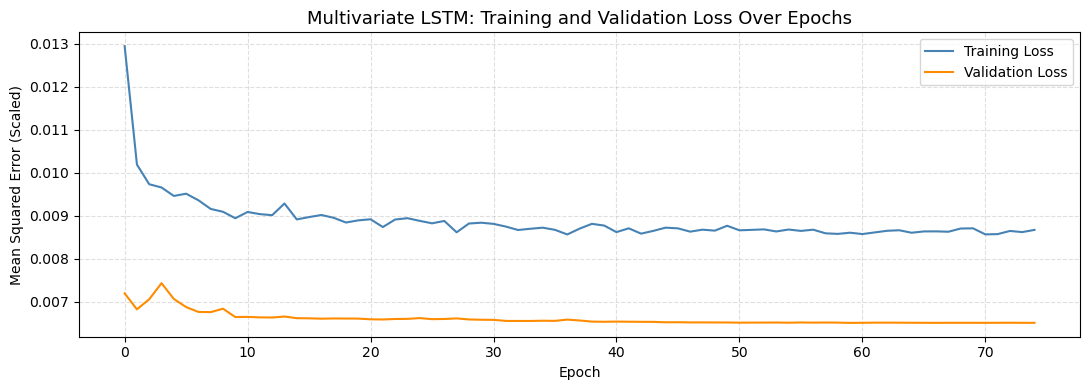

Training stopped at epoch 75. Best validation loss: 0.006514
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

Predictions shape  : (768,)
Actual values shape: (768,)

First 5 predicted returns : [ 4.38e-04  3.20e-05  2.83e-04 -4.61e-04 -2.99e-04]
First 5 actual returns    : [-0.001723 -0.013726  0.010333 -0.014759  0.000124]


In [14]:
# ── Ploting the training and validation loss curves 
plt.figure(figsize=(11, 4))
plt.plot(history.history["loss"],     color="steelblue",  linewidth=1.5, label="Training Loss")
plt.plot(history.history["val_loss"], color="darkorange", linewidth=1.5, label="Validation Loss")
# Both curves should decline together and stabilise; a growing gap signals overfitting
plt.title("Multivariate LSTM: Training and Validation Loss Over Epochs", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (Scaled)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Training stopped at epoch {epochs_run}. "
      f"Best validation loss: {min(history.history['val_loss']):.6f}")

# ── Generating predictions on the test set 
# The model outputs predictions in the scaled 0-to-1 space
# We must reverse the scaling to get predictions in the original return units
test_predictions_scaled = model.predict(X_test)
# model.predict() passes each test sequence through the trained network
# Output shape: (n_test_samples, 1)

# ── Reversing the scaling on predictions 
# The scaler was fitted on all features simultaneously
# To inverse-transform just the target column, we must reconstruct a full-width array
# then extract only the target column after inverse-transforming

# Creating a dummy array of zeros with the same number of columns as the full feature set
dummy_pred = np.zeros((len(test_predictions_scaled), train_scaled.shape[1]))
# shape: (n_test_samples, n_features) filled with zeros

# Placing the model predictions into the target column position
dummy_pred[:, target_col_index] = test_predictions_scaled.flatten()
# flatten() converts shape (n,1) to shape (n,) for assignment

# Applying inverse_transform to the full dummy array
dummy_pred_inv = scaler.inverse_transform(dummy_pred)
# inverse_transform reverses the MinMax scaling: value = scaled * (max - min) + min

# Extracting only the target column from the inverse-transformed array
test_predictions = dummy_pred_inv[:, target_col_index]
# This gives us the predicted USDZAR_Return values in original (unscaled) units

# ── Reversing the scaling on the actual test target values 
# y_test is also in scaled form and must be reversed the same way
dummy_actual = np.zeros((len(y_test), train_scaled.shape[1]))
# Another dummy array of zeros with the same shape
dummy_actual[:, target_col_index] = y_test.flatten()
dummy_actual_inv = scaler.inverse_transform(dummy_actual)
y_test_actual = dummy_actual_inv[:, target_col_index]
# y_test_actual now contains the real USDZAR_Return values for the test period

# ── Confirming shapes match before computing metrics 
print(f"\nPredictions shape  : {test_predictions.shape}")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"\nFirst 5 predicted returns : {test_predictions[:5].round(6)}")
print(f"First 5 actual returns    : {y_test_actual[:5].round(6)}")

   MULTIVARIATE LSTM EVALUATION METRICS
RMSE (log return units)  : 0.018039
MAE  (log return units)  : 0.008135
Directional Accuracy     : 59.64%


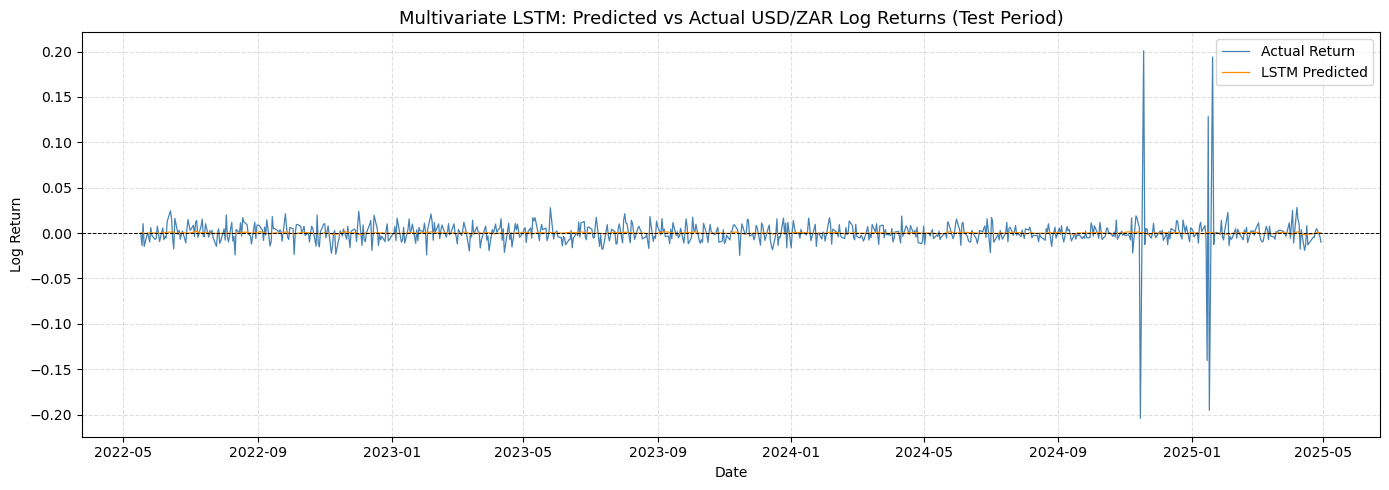

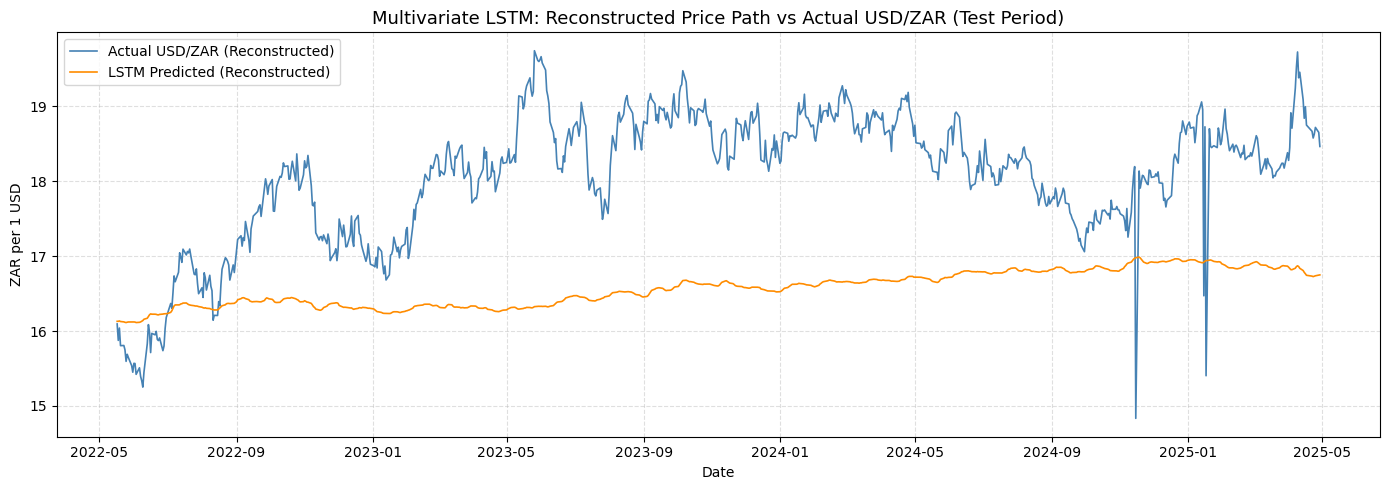


Note: RMSE and MAE are in log return units, not ZAR.
For reference: a log return RMSE of 0.005 corresponds to approximately 0.5% daily error.

Directional Accuracy of 59.64% means the model correctly predicted
the direction of ZAR movement on 59.64% of test days.


In [15]:
# ── Computing RMSE and MAE on log returns 
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predictions))
# RMSE: square root of average squared error, in log return units
mae  = mean_absolute_error(y_test_actual, test_predictions)
# MAE: average absolute error, equally weighting all prediction errors

# ── Computing directional accuracy 
# Directional accuracy measures how often the model correctly predicts
# whether the ZAR will strengthen or weaken the next day
actual_direction    = np.sign(y_test_actual)
# np.sign converts each return to: +1 (ZAR weakens), -1 (ZAR strengthens), 0 (flat)
predicted_direction = np.sign(test_predictions)
# Same conversion applied to the predicted returns

directional_accuracy = np.mean(actual_direction == predicted_direction) * 100
# Percentage of days where predicted and actual directions match
# 50% = chance performance; anything above ~52% sustained is meaningful

# ── Printing the evaluation metrics 
print("=" * 45)
print("   MULTIVARIATE LSTM EVALUATION METRICS")
print("=" * 45)
print(f"RMSE (log return units)  : {rmse:.6f}")
print(f"MAE  (log return units)  : {mae:.6f}")
print(f"Directional Accuracy     : {directional_accuracy:.2f}%")
print("=" * 45)

# ── Getting the test dates aligned to the prediction window 
test_dates = test_df.index[LOOKBACK:]
# The first LOOKBACK rows of the test set are consumed as the first input window
# So predictions start from row LOOKBACK of the test set

# ── Plotting predicted vs actual log returns 
plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test_actual,   color="steelblue",  linewidth=0.9, label="Actual Return")
plt.plot(test_dates, test_predictions, color="darkorange", linewidth=0.9, label="LSTM Predicted")
plt.axhline(0, color="black", linewidth=0.7, linestyle="--")
plt.title("Multivariate LSTM: Predicted vs Actual USD/ZAR Log Returns (Test Period)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Reconstructing the price series from cumulative log returns 
# Cumulative sum of log returns gives the log price relative to the start
# This lets us visualise predictions in ZAR price terms for interpretability

# Getting the actual USD/ZAR price level at the start of the test prediction window
start_price = df["USDZAR"].iloc[split_index + LOOKBACK]
# This is the actual exchange rate on the first day of our prediction window

# Reconstructing actual and predicted price paths from cumulative returns
actual_prices_reconstructed    = start_price * np.exp(np.cumsum(y_test_actual))
predicted_prices_reconstructed = start_price * np.exp(np.cumsum(test_predictions))
# np.cumsum computes running sum of log returns
# np.exp converts log price back to price level
# Multiplying by start_price anchors both paths to the same starting value

# ── Ploting reconstructed price paths 
plt.figure(figsize=(14, 5))
plt.plot(test_dates, actual_prices_reconstructed,    color="steelblue",  linewidth=1.2, label="Actual USD/ZAR (Reconstructed)")
plt.plot(test_dates, predicted_prices_reconstructed, color="darkorange", linewidth=1.2, label="LSTM Predicted (Reconstructed)")
plt.title("Multivariate LSTM: Reconstructed Price Path vs Actual USD/ZAR (Test Period)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("ZAR per 1 USD")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Printing a note on units 
print("\nNote: RMSE and MAE are in log return units, not ZAR.")
print("For reference: a log return RMSE of 0.005 corresponds to approximately 0.5% daily error.")
print(f"\nDirectional Accuracy of {directional_accuracy:.2f}% means the model correctly predicted")
print(f"the direction of ZAR movement on {directional_accuracy:.2f}% of test days.")

In [16]:
# ── Building the random walk benchmark on log returns 
# The random walk predicts that tomorrow's log return will be zero
# This is equivalent to saying: tomorrow's price = today's price
# Under the efficient market hypothesis, this is the hardest benchmark to beat
# because it implies that all available information is already priced in

# ── The random walk forecast for log returns is always zero 
rw_predictions = np.zeros(len(y_test_actual))
# np.zeros creates an array of zeros the same length as our test set
# Each zero is the random walk's prediction: "no change expected tomorrow"

# ── Computing RMSE and MAE for the random walk 
rw_rmse = np.sqrt(mean_squared_error(y_test_actual, rw_predictions))
# RMSE of predicting zero every day: measures how volatile the returns actually are
rw_mae  = mean_absolute_error(y_test_actual, rw_predictions)
# MAE of predicting zero every day: average absolute daily return magnitude

# ── Computing directional accuracy for the random walk
# The random walk predicts zero return every day (signal = 0)
# When the actual return is also zero, it is counted as correct
# When the actual return is positive or negative, the random walk is wrong
# In practice this means directional accuracy is close to 50% since returns
# are approximately symmetrically distributed around zero
rw_direction = np.zeros(len(y_test_actual))
# All zeros: the random walk never predicts a directional move
rw_dir_accuracy = np.mean(np.sign(y_test_actual) == np.sign(rw_direction)) * 100
# Days where actual return is exactly zero will count as correct
# Days where actual return is nonzero (almost all days) will count as incorrect

# ── Printing random walk benchmark results 
print("=" * 45)
print("     RANDOM WALK BENCHMARK METRICS")
print("=" * 45)
print(f"RMSE (log return units)  : {rw_rmse:.6f}")
print(f"MAE  (log return units)  : {rw_mae:.6f}")
print(f"Directional Accuracy     : {rw_dir_accuracy:.2f}%")
print("=" * 45)
print("\nInterpretation:")
print("The random walk RMSE equals the standard deviation of daily log returns.")
print("If LSTM RMSE < Random Walk RMSE, the LSTM has genuine predictive value.")
print("Directional accuracy near 0% is expected: the random walk always predicts zero.")
print("A LSTM directional accuracy above 50% meaningfully beats this baseline.")

     RANDOM WALK BENCHMARK METRICS
RMSE (log return units)  : 0.018111
MAE  (log return units)  : 0.008258
Directional Accuracy     : 0.00%

Interpretation:
The random walk RMSE equals the standard deviation of daily log returns.
If LSTM RMSE < Random Walk RMSE, the LSTM has genuine predictive value.
Directional accuracy near 0% is expected: the random walk always predicts zero.
A LSTM directional accuracy above 50% meaningfully beats this baseline.


In [17]:
# ── Fitting auto_arima on the training set log returns 
# Note: we now fit ARIMA on USDZAR_Return (log returns) not raw prices
# Log returns are stationary so d=0 is appropriate here
# We let auto_arima decide the best p and q orders
print("Fitting ARIMA model on training log returns...")
print("This may take a minute while auto_arima searches for the best order.\n")

arima_model = auto_arima(
    train_df[TARGET],
    # train_df[TARGET] is the USDZAR_Return column from the original unscaled training set
    start_p=1, start_q=1,
    # minimum AR and MA orders to search from
    max_p=5, max_q=5,
    # maximum AR and MA orders to search up to
    d=0,
    # d=0 because log returns are already stationary
    # we do not need to difference them again
    seasonal=False,
    # no seasonal component for daily FX returns
    information_criterion="aic",
    # AIC balances model fit against complexity
    stepwise=True,
    # stepwise search is much faster than an exhaustive grid search
    suppress_warnings=True,
    error_action="ignore"
)

print(f"Best ARIMA order selected: {arima_model.order}")
print(arima_model.summary())

Fitting ARIMA model on training log returns...
This may take a minute while auto_arima searches for the best order.

Best ARIMA order selected: (0, 0, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3188
Model:                        SARIMAX   Log Likelihood               10273.260
Date:                Wed, 20 May 2026   AIC                         -20544.520
Time:                        06:15:50   BIC                         -20538.453
Sample:                             0   HQIC                        -20542.344
                               - 3188                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      9.301e-05   1.69e-06     54.999      0.000  

In [18]:
# ── Generating one-step-ahead rolling ARIMA forecasts 
# We use the same fast SARIMAX approach from the previous project
# Fit ONCE on training data, then update with each new observation using refit=False

p, d, q = arima_model.order
# Extracting the best (p, d, q) order found by auto_arima

print(f"Generating rolling ARIMA({p},{d},{q}) forecasts on log returns...")
print("Fitting SARIMAX on training data once...")

# ── Fitting SARIMAX once on the full training log return series 
sarimax_model = SARIMAX(
    train_df[TARGET],
    # fit on the USDZAR_Return column from the unscaled training set
    order=(p, d, q),
    enforce_stationarity=False,
    # suppress errors if borderline stationarity issues arise
    enforce_invertibility=False
    # suppress errors on some MA parameter combinations
).fit(disp=False)
# disp=False suppresses the fitting output to keep the notebook clean

print("SARIMAX fitted. Starting rolling forecasts...")

# ── Rolling forward through the test set one day at a time 
arima_predictions = []
# store each one-step forecast in this list

for i in range(len(test_df)):
    # Forecast one day ahead from the current model state
    forecast = sarimax_model.forecast(steps=1)
    # forecast(steps=1) predicts exactly the next day's log return
    arima_predictions.append(forecast.iloc[0])
    # iloc[0] extracts the single forecasted value

    # Updating the model with the true observed log return for this day
    sarimax_model = sarimax_model.append(
        [test_df[TARGET].iloc[i]],
        # test_df[TARGET].iloc[i] is the actual USDZAR_Return for day i
        refit=False
        # refit=False: update the filter state without re-estimating parameters
        # this is fast: milliseconds per step instead of minutes
    )

    # Print progress every 100 days
    if (i + 1) % 100 == 0:
        print(f"  Completed {i + 1} / {len(test_df)} forecasts...")

# ── Converting list to numpy array 
arima_predictions = np.array(arima_predictions)

# ── Align ARIMA predictions to the same window as LSTM predictions 
# LSTM predictions start LOOKBACK days into the test set
# We slice ARIMA predictions to match exactly the same date window
arima_preds_aligned  = arima_predictions[LOOKBACK:]
arima_actual_aligned = test_df[TARGET].values[LOOKBACK:]
# Both arrays now cover the same date range as the LSTM test predictions

print(f"\nARIMA forecasts generated : {len(arima_preds_aligned)} predictions")
print(f"First 5 ARIMA predictions : {arima_preds_aligned[:5].round(6)}")

# ── Computing ARIMA evaluation metrics 
arima_rmse = np.sqrt(mean_squared_error(arima_actual_aligned, arima_preds_aligned))
arima_mae  = mean_absolute_error(arima_actual_aligned, arima_preds_aligned)

# Directional accuracy for ARIMA
arima_dir_accuracy = np.mean(
    np.sign(arima_actual_aligned) == np.sign(arima_preds_aligned)
) * 100

print("\n" + "=" * 45)
print("       ARIMA BENCHMARK METRICS")
print("=" * 45)
print(f"RMSE (log return units)  : {arima_rmse:.6f}")
print(f"MAE  (log return units)  : {arima_mae:.6f}")
print(f"Directional Accuracy     : {arima_dir_accuracy:.2f}%")
print("=" * 45)

Generating rolling ARIMA(0,0,0) forecasts on log returns...
Fitting SARIMAX on training data once...
SARIMAX fitted. Starting rolling forecasts...
  Completed 100 / 798 forecasts...
  Completed 200 / 798 forecasts...
  Completed 300 / 798 forecasts...
  Completed 400 / 798 forecasts...
  Completed 500 / 798 forecasts...
  Completed 600 / 798 forecasts...
  Completed 700 / 798 forecasts...

ARIMA forecasts generated : 768 predictions
First 5 ARIMA predictions : [0. 0. 0. 0. 0.]

       ARIMA BENCHMARK METRICS
RMSE (log return units)  : 0.018111
MAE  (log return units)  : 0.008258
Directional Accuracy     : 0.00%


y_test_actual length        : 768
test_predictions length     : 768
arima_predictions length    : 798
arima_preds_aligned length  : 768
test_df length              : 798
LOOKBACK                    : 30

Aligning all predictions to minimum shared length: 768

After alignment:
  y_aligned     : 768
  lstm_aligned  : 768
  arima_aligned : 768
  rw_aligned    : 768
  dates_aligned : 768

   MULTIVARIATE LSTM vs ARIMA vs RANDOM WALK: FULL COMPARISON
                  Metric  LSTM (Multivariate)    ARIMA  Random Walk Best Model
       RMSE (log return)             0.018039 0.018111     0.018111       LSTM
        MAE (log return)             0.008135 0.008258     0.008258       LSTM
Directional Accuracy (%)            59.640000 0.000000     0.000000       LSTM


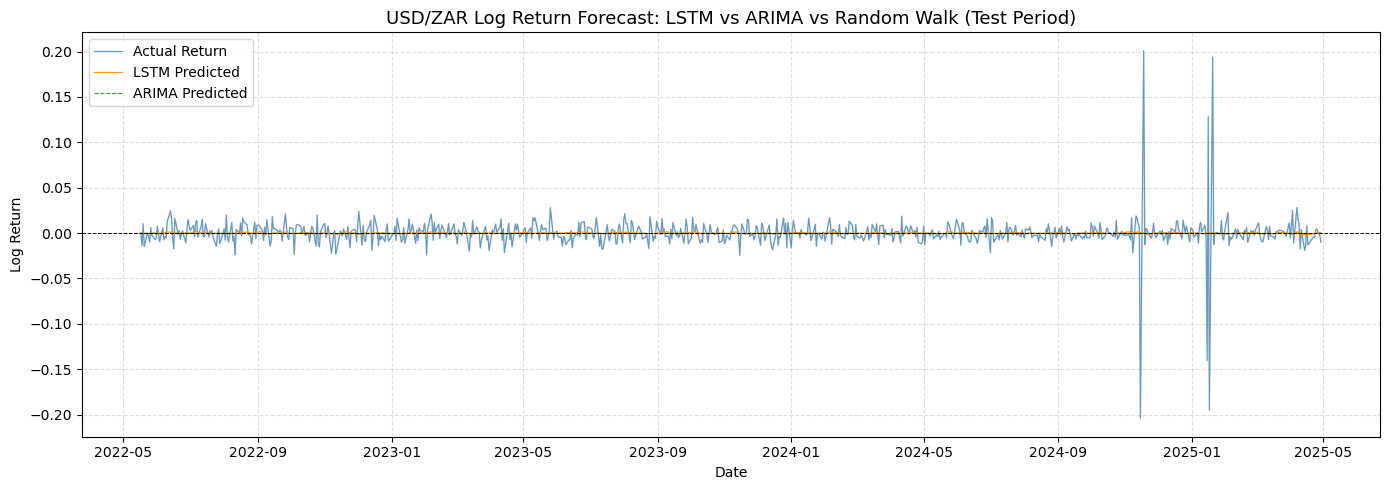

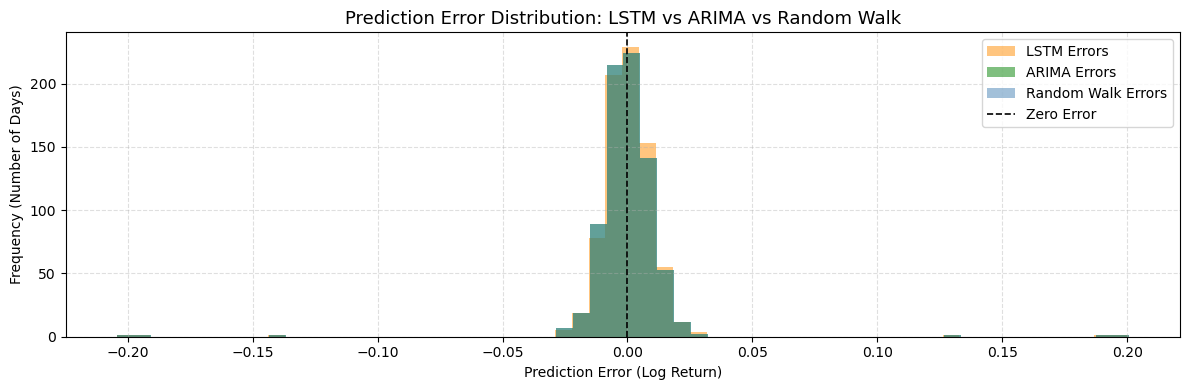


Model                Mean Error (Bias)      Std Dev of Errors
------------------------------------------------------------
LSTM                 0.000127               0.018039
ARIMA                0.000177               0.018110
Random Walk          0.000177               0.018110

Aligned arrays stored for trading strategy in Cell 20.


In [20]:
# ── Diagnosing the lengths before aligning 
print(f"y_test_actual length        : {len(y_test_actual)}")
print(f"test_predictions length     : {len(test_predictions)}")
print(f"arima_predictions length    : {len(arima_predictions)}")
print(f"arima_preds_aligned length  : {len(arima_preds_aligned)}")
print(f"test_df length              : {len(test_df)}")
print(f"LOOKBACK                    : {LOOKBACK}")

# ── Recomputing alignment using the minimum shared length 
# y_test_actual and test_predictions come from the LSTM sequence builder
# They start at row LOOKBACK of the test set and run to the end
# arima_predictions covers the full test_df length
# We align everything to the shortest common window to ensure equal lengths

min_len = min(len(y_test_actual), len(test_predictions), len(arima_preds_aligned))
# min_len is the number of days covered by ALL three models simultaneously
print(f"\nAligning all predictions to minimum shared length: {min_len}")

# ── Slicing all arrays to the same minimum length 
y_aligned         = y_test_actual[:min_len]
# actual log returns, trimmed to min_len
lstm_aligned      = test_predictions[:min_len]
# LSTM predicted log returns, trimmed to min_len
arima_aligned     = arima_preds_aligned[:min_len]
# ARIMA predicted log returns, trimmed to min_len
rw_aligned        = np.zeros(min_len)
# random walk predicts zero every day, length matched to min_len
dates_aligned     = test_dates[:min_len]
# corresponding dates for plotting, trimmed to min_len

# ── Confirming all lengths now match 
print(f"\nAfter alignment:")
print(f"  y_aligned     : {len(y_aligned)}")
print(f"  lstm_aligned  : {len(lstm_aligned)}")
print(f"  arima_aligned : {len(arima_aligned)}")
print(f"  rw_aligned    : {len(rw_aligned)}")
print(f"  dates_aligned : {len(dates_aligned)}")

# ── Computing metrics for all three models on the aligned window 
# LSTM metrics
lstm_rmse = np.sqrt(mean_squared_error(y_aligned, lstm_aligned))
lstm_mae  = mean_absolute_error(y_aligned, lstm_aligned)
lstm_dir  = np.mean(np.sign(y_aligned) == np.sign(lstm_aligned)) * 100

# ARIMA metrics
arima_rmse_a = np.sqrt(mean_squared_error(y_aligned, arima_aligned))
arima_mae_a  = mean_absolute_error(y_aligned, arima_aligned)
arima_dir_a  = np.mean(np.sign(y_aligned) == np.sign(arima_aligned)) * 100

# Random walk metrics
rw_rmse_a = np.sqrt(mean_squared_error(y_aligned, rw_aligned))
rw_mae_a  = mean_absolute_error(y_aligned, rw_aligned)
rw_dir_a  = np.mean(np.sign(y_aligned) == np.sign(rw_aligned)) * 100

# ── Building the comparison table 
comparison = pd.DataFrame({
    "Metric": ["RMSE (log return)", "MAE (log return)", "Directional Accuracy (%)"],
    "LSTM (Multivariate)": [round(lstm_rmse, 6), round(lstm_mae, 6), round(lstm_dir, 2)],
    "ARIMA":               [round(arima_rmse_a, 6), round(arima_mae_a, 6), round(arima_dir_a, 2)],
    "Random Walk":         [round(rw_rmse_a, 6), round(rw_mae_a, 6), round(rw_dir_a, 2)],
})

# ── Adding best model column 
comparison["Best Model"] = [
    min({"LSTM": lstm_rmse, "ARIMA": arima_rmse_a, "Random Walk": rw_rmse_a}, key=lambda k: {"LSTM": lstm_rmse, "ARIMA": arima_rmse_a, "Random Walk": rw_rmse_a}[k]),
    min({"LSTM": lstm_mae,  "ARIMA": arima_mae_a,  "Random Walk": rw_mae_a},  key=lambda k: {"LSTM": lstm_mae,  "ARIMA": arima_mae_a,  "Random Walk": rw_mae_a}[k]),
    max({"LSTM": lstm_dir,  "ARIMA": arima_dir_a,  "Random Walk": rw_dir_a},  key=lambda k: {"LSTM": lstm_dir,  "ARIMA": arima_dir_a,  "Random Walk": rw_dir_a}[k]),
]

# ── Printing the full comparison table 
print("\n" + "=" * 75)
print("   MULTIVARIATE LSTM vs ARIMA vs RANDOM WALK: FULL COMPARISON")
print("=" * 75)
print(comparison.to_string(index=False))
print("=" * 75)

# ── Ploting all three model predictions against actual returns 
plt.figure(figsize=(14, 5))
plt.plot(dates_aligned, y_aligned,      color="steelblue",  linewidth=0.9, label="Actual Return", alpha=0.8)
plt.plot(dates_aligned, lstm_aligned,   color="darkorange", linewidth=0.9, label="LSTM Predicted", alpha=0.9)
plt.plot(dates_aligned, arima_aligned,  color="green",      linewidth=0.8, linestyle="--", label="ARIMA Predicted", alpha=0.8)
plt.axhline(0, color="black", linewidth=0.7, linestyle="--")
plt.fill_between(dates_aligned, y_aligned, 0, alpha=0.07, color="steelblue")
plt.title("USD/ZAR Log Return Forecast: LSTM vs ARIMA vs Random Walk (Test Period)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Ploting prediction error distributions 
lstm_errors  = y_aligned - lstm_aligned
arima_errors = y_aligned - arima_aligned
rw_errors    = y_aligned - rw_aligned

plt.figure(figsize=(12, 4))
plt.hist(lstm_errors,  bins=60, alpha=0.5, color="darkorange", label="LSTM Errors")
plt.hist(arima_errors, bins=60, alpha=0.5, color="green",      label="ARIMA Errors")
plt.hist(rw_errors,    bins=60, alpha=0.5, color="steelblue",  label="Random Walk Errors")
plt.axvline(0, color="black", linewidth=1.2, linestyle="--", label="Zero Error")
plt.title("Prediction Error Distribution: LSTM vs ARIMA vs Random Walk", fontsize=13)
plt.xlabel("Prediction Error (Log Return)")
plt.ylabel("Frequency (Number of Days)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Printing error bias and spread 
print(f"\n{'Model':<20} {'Mean Error (Bias)':<22} {'Std Dev of Errors'}")
print("-" * 60)
print(f"{'LSTM':<20} {lstm_errors.mean():<22.6f} {lstm_errors.std():.6f}")
print(f"{'ARIMA':<20} {arima_errors.mean():<22.6f} {arima_errors.std():.6f}")
print(f"{'Random Walk':<20} {rw_errors.mean():<22.6f} {rw_errors.std():.6f}")

# ── Storing aligned arrays for use in Cell 20 
# These will be used by the trading strategy cell
y_test_final    = y_aligned
lstm_preds_final = lstm_aligned
test_dates_final = dates_aligned
print("\nAligned arrays stored for trading strategy in Cell 20.")

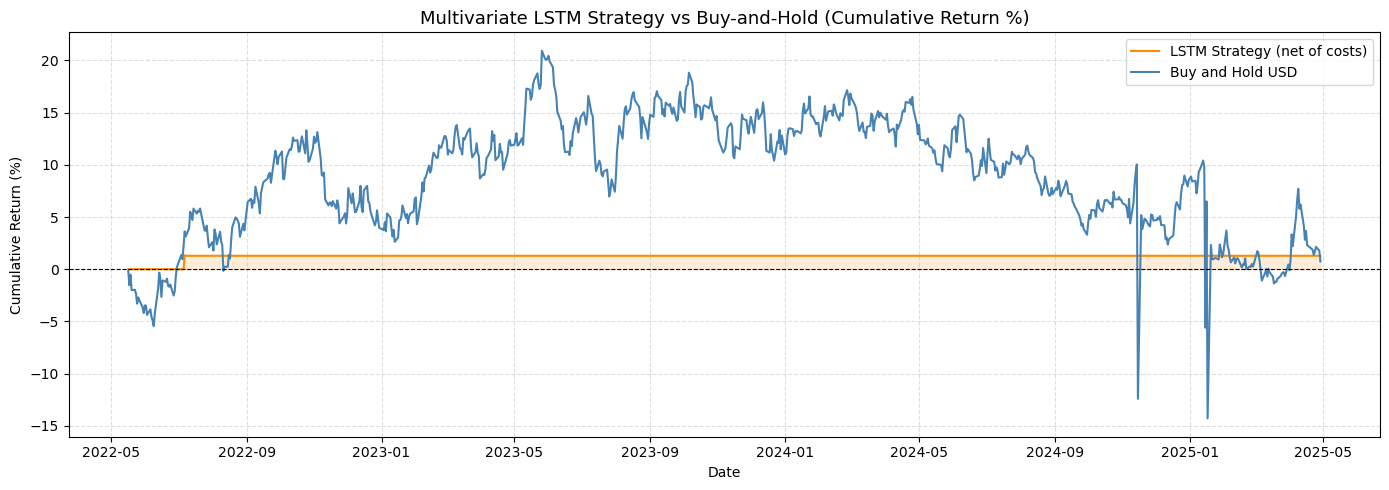

  MULTIVARIATE LSTM TRADING STRATEGY METRICS
Total Strategy Return    : 1.29%
Buy-and-Hold Return      : 0.75%
Annualised Sharpe Ratio  : 0.5514
Maximum Drawdown         : -0.05%
Number of Trades         : 2
Signal Threshold         : 0.2% predicted log return

Note: A Sharpe ratio above 1.0 is considered acceptable.
A Sharpe ratio above 2.0 is considered strong for an FX strategy.


In [21]:
# ── Building the directional trading strategy using the aligned LSTM predictions 
# We use lstm_preds_final and y_test_final which were aligned in Cell 19
# This ensures the strategy uses the same consistent window as the comparison table

# ── Setting the signal threshold 
THRESHOLD = 0.002
# Only trade when the predicted log return exceeds 0.2% in magnitude
# This filters out small predicted moves that are more likely to be noise
# than genuine directional signals

# ── Generating trading signals 
signals = np.where(
    lstm_preds_final > THRESHOLD, 1,
    # Predicted positive return above threshold: go LONG USD (ZAR weakening expected)
    np.where(lstm_preds_final < -THRESHOLD, -1, 0)
    # Predicted negative return below threshold: go SHORT USD (ZAR strengthening expected)
    # Within the threshold band: stay FLAT (signal = 0, no position held)
)

# ── Computing strategy returns 
strategy_returns = signals * y_test_final
# signal = +1 and ZAR weakens (positive return): profit
# signal = -1 and ZAR strengthens (negative return): profit (double negative = positive)
# signal = 0: zero return for that day regardless of what the market does

# ── Apply round-trip transaction costs 
TRANSACTION_COST = 0.0005
# 0.05% per trade, reflecting a realistic FX spread for institutional participants

position_changes = np.abs(np.diff(np.append(0, signals)))
# np.diff detects when the signal changes from one day to the next
# np.abs makes all values positive since costs are paid regardless of direction
# np.append(0, signals) adds a zero at the start representing no initial position

cost_per_day = position_changes * TRANSACTION_COST
# cost_per_day is nonzero only on days when we change position

strategy_returns_net = strategy_returns - cost_per_day
# Net return = gross strategy return minus transaction cost for that day

# ── Computing cumulative returns 
cumulative_strategy = np.cumprod(1 + strategy_returns_net) - 1
# Running product of (1 + daily net return) minus 1 gives total compounded return

cumulative_buy_hold = np.cumprod(1 + y_test_final) - 1
# Buy-and-hold: hold USD throughout the entire test period
# This captures the full ZAR depreciation trend as a passive benchmark

# ── Computing strategy performance metrics 
total_return = cumulative_strategy[-1] * 100
# Total percentage return of the LSTM strategy over the full aligned test window

bh_return = cumulative_buy_hold[-1] * 100
# Total percentage return of the buy-and-hold benchmark over the same window

sharpe_ratio = (strategy_returns_net.mean() / strategy_returns_net.std()) * np.sqrt(252)
# Annualised Sharpe ratio: mean daily net return divided by its standard deviation
# multiplied by sqrt(252) to convert from daily to annual scale
# 252 is the standard number of trading days in a year

max_drawdown = np.min(
    cumulative_strategy - np.maximum.accumulate(cumulative_strategy)
) * 100
# Maximum drawdown: largest peak-to-trough decline in cumulative strategy returns
# np.maximum.accumulate tracks the highest cumulative return reached up to each day

num_trades = int(np.sum(position_changes > 0))
# Counting the number of days where a position change occurred (a trade was made)

# ── Ploting cumulative returns: strategy vs buy-and-hold 
plt.figure(figsize=(14, 5))
plt.plot(test_dates_final, cumulative_strategy * 100,
         color="darkorange", linewidth=1.5, label="LSTM Strategy (net of costs)")
plt.plot(test_dates_final, cumulative_buy_hold * 100,
         color="steelblue", linewidth=1.5, label="Buy and Hold USD")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.fill_between(test_dates_final, cumulative_strategy * 100, 0,
                 alpha=0.15, color="darkorange")
# Shading highlights the cumulative gain or loss of the strategy over time
plt.title("Multivariate LSTM Strategy vs Buy-and-Hold (Cumulative Return %)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# ── Printing the full strategy performance summary 
print("=" * 50)
print("  MULTIVARIATE LSTM TRADING STRATEGY METRICS")
print("=" * 50)
print(f"Total Strategy Return    : {total_return:.2f}%")
print(f"Buy-and-Hold Return      : {bh_return:.2f}%")
print(f"Annualised Sharpe Ratio  : {sharpe_ratio:.4f}")
print(f"Maximum Drawdown         : {max_drawdown:.2f}%")
print(f"Number of Trades         : {num_trades}")
print(f"Signal Threshold         : {THRESHOLD*100:.1f}% predicted log return")
print("=" * 50)
print("\nNote: A Sharpe ratio above 1.0 is considered acceptable.")
print("A Sharpe ratio above 2.0 is considered strong for an FX strategy.")

Baseline MSE (scaled): 0.028963

Computing permutation importance (this may take a minute)...


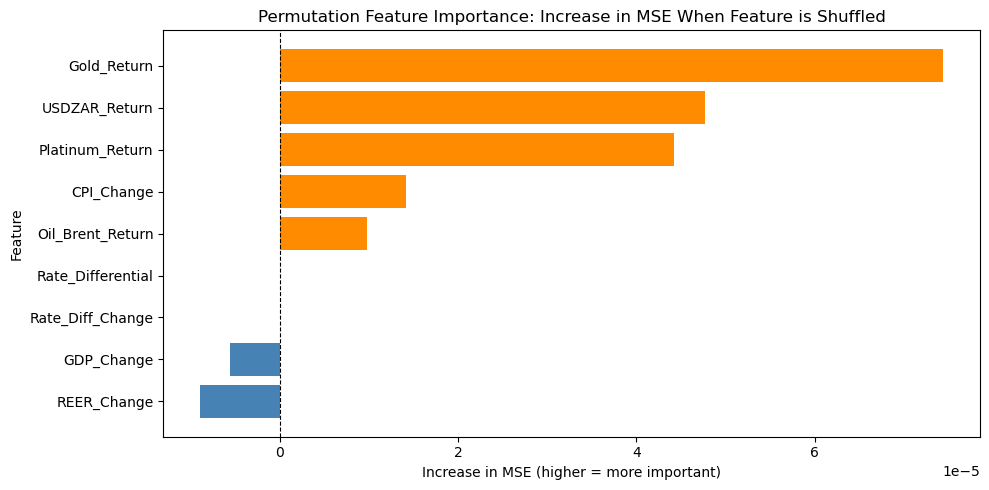


Feature Importance Rankings:
          Feature  Importance
      Gold_Return    0.000074
    USDZAR_Return    0.000048
  Platinum_Return    0.000044
       CPI_Change    0.000014
 Oil_Brent_Return    0.000010
Rate_Differential    0.000000
 Rate_Diff_Change    0.000000
       GDP_Change   -0.000006
      REER_Change   -0.000009

Interpretation: Features with the largest positive importance score
contributed the most to the LSTM's predictive accuracy.
Features near zero had little impact on model performance.


In [23]:
# ── Computing permutation feature importance 
# Permutation importance measures how much model performance degrades
# when a single feature is randomly shuffled (its information is destroyed)
# A large drop in performance when a feature is shuffled means that feature
# was contributing meaningfully to the model's predictions
# A small drop means the model was not relying on that feature much

from sklearn.metrics import mean_squared_error as mse_fn

# ── Compute the baseline MSE on the test set using the trained model 
baseline_preds = model.predict(X_test, verbose=0).flatten()
# Get the model's predictions on the unmodified test sequences
baseline_mse   = mse_fn(y_test, baseline_preds)
# Computing the baseline MSE using scaled y_test values for consistency
print(f"Baseline MSE (scaled): {baseline_mse:.6f}")

# ── Get the feature names in the order they appear in the model input 
feature_names = list(model_df.columns)
# model_df columns are in the same order as the columns in X_train and X_test

# ── Loop through each feature and measure the MSE when it is permuted 
importance_scores = {}
# Dictionary to store the importance score for each feature

print("\nComputing permutation importance (this may take a minute)...")

for col_idx, col_name in enumerate(feature_names):
    # Make a copy of the test sequences so we do not modify the originals
    X_test_permuted = X_test.copy()
    # X_test shape: (samples, LOOKBACK, n_features)

    # Randomly shuffle the values of this feature across all timesteps and samples
    shuffled_values = X_test_permuted[:, :, col_idx].flatten()
    # flatten() converts the 2D slice (samples x timesteps) to a 1D array
    np.random.shuffle(shuffled_values)
    # shuffle() randomly reorders the values, destroying any predictive signal
    X_test_permuted[:, :, col_idx] = shuffled_values.reshape(
        X_test_permuted[:, :, col_idx].shape
    )
    # reshape puts the shuffled values back into the original (samples, timesteps) shape

    # Get model predictions with this feature permuted
    permuted_preds = model.predict(X_test_permuted, verbose=0).flatten()
    permuted_mse   = mse_fn(y_test, permuted_preds)
    # MSE after permuting this feature

    # Importance = increase in MSE when feature is destroyed
    importance_scores[col_name] = permuted_mse - baseline_mse
    # A larger positive value means the feature was more important
    # A value near zero means the model did not rely on this feature much

# ── Sorting features by importance 
importance_df = pd.DataFrame({
    "Feature"   : list(importance_scores.keys()),
    "Importance": list(importance_scores.values())
}).sort_values("Importance", ascending=False).reset_index(drop=True)
# Sort descending so the most important feature appears at the top

# ── Plottig the feature importance chart 
plt.figure(figsize=(10, 5))
colors_bar = ["darkorange" if v > 0 else "steelblue" for v in importance_df["Importance"]]
# Orange bars for features that increased MSE (important)
# Blue bars for features that decreased MSE (less meaningful)
plt.barh(importance_df["Feature"], importance_df["Importance"], color=colors_bar)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Permutation Feature Importance: Increase in MSE When Feature is Shuffled", fontsize=12)
plt.xlabel("Increase in MSE (higher = more important)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
# invert_yaxis puts the most important feature at the top of the chart
plt.tight_layout()
plt.show()

# ── Printing the importance table 
print("\nFeature Importance Rankings:")
print(importance_df.to_string(index=False))
print("\nInterpretation: Features with the largest positive importance score")
print("contributed the most to the LSTM's predictive accuracy.")
print("Features near zero had little impact on model performance.")

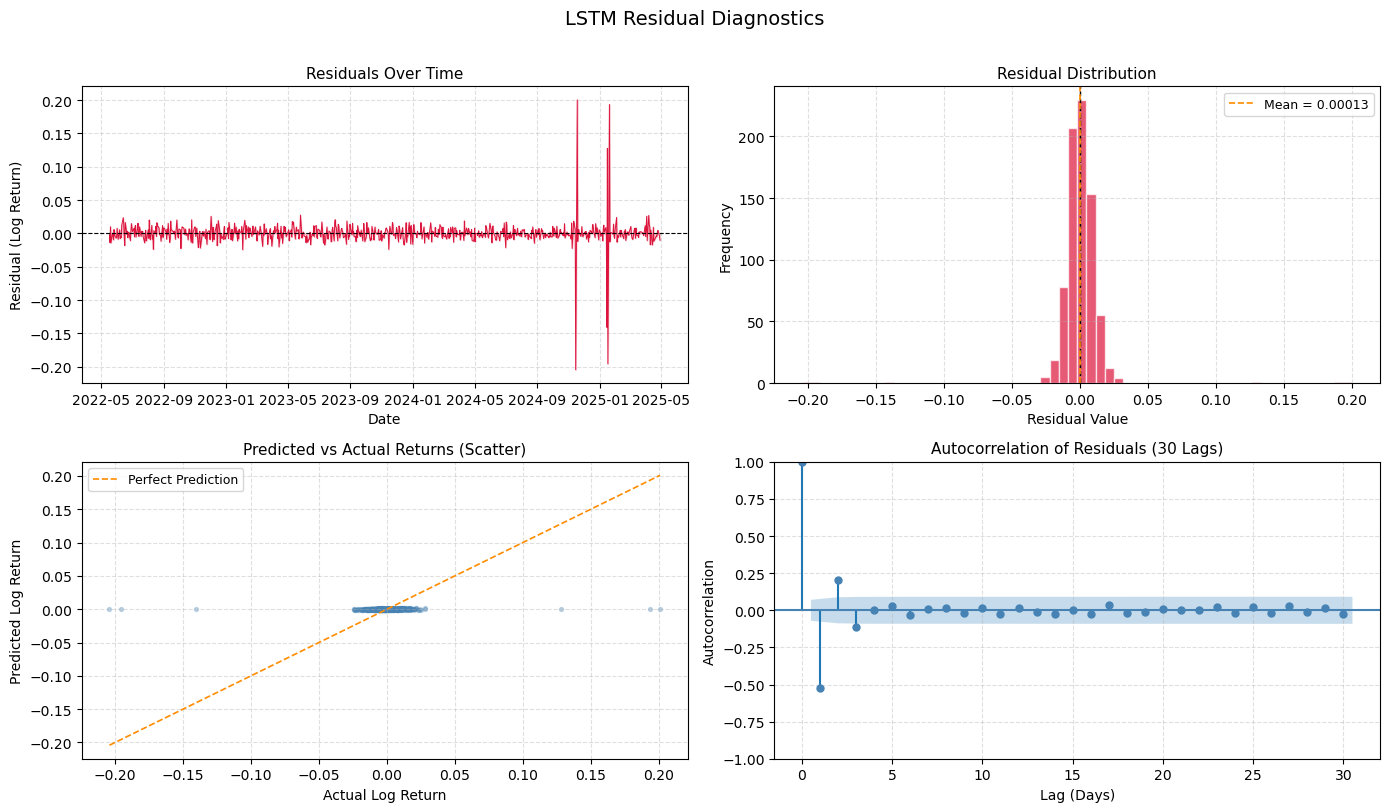

Residual Summary Statistics:
  Mean (Bias)      : 0.000127
  Std Dev          : 0.018039
  Skewness         : -0.3328
  Kurtosis         : 82.3566
  Min              : -0.204478
  Max              : 0.200342

Interpretation:
Mean near zero: no systematic bias in predictions.
High kurtosis: fat-tailed residuals, typical of financial return series.
ACF bars within bands: residuals are approximately white noise (no learnable pattern left).


In [24]:
# ── Computing prediction errors (residuals) for the LSTM on the aligned test window ──
residuals = y_test_final - lstm_preds_final
# residuals[i] = actual return on day i minus predicted return on day i
# If residuals are random (no pattern), the model has extracted all available signal
# If residuals show patterns, the model has missed something learnable

# ── Plot 1: Residuals over time 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# Create a 2x2 grid of diagnostic plots

axes[0, 0].plot(test_dates_final, residuals, color="crimson", linewidth=0.7)
axes[0, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0, 0].fill_between(test_dates_final, residuals, 0, alpha=0.2, color="crimson")
axes[0, 0].set_title("Residuals Over Time", fontsize=11)
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Residual (Log Return)")
axes[0, 0].grid(True, linestyle="--", alpha=0.4)
# If residuals are small and random around zero, the model is well-calibrated

# ── Plot 2: Residual distribution (histogram) 
axes[0, 1].hist(residuals, bins=60, color="crimson", alpha=0.7, edgecolor="white")
axes[0, 1].axvline(0, color="black", linewidth=1.0, linestyle="--")
axes[0, 1].axvline(residuals.mean(), color="darkorange", linewidth=1.2,
                   linestyle="--", label=f"Mean = {residuals.mean():.5f}")
axes[0, 1].set_title("Residual Distribution", fontsize=11)
axes[0, 1].set_xlabel("Residual Value")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, linestyle="--", alpha=0.4)
# A distribution centred at zero indicates no systematic bias

# ── Plot 3: Predicted vs actual scatter plot 
axes[1, 0].scatter(y_test_final, lstm_preds_final,
                   alpha=0.3, color="steelblue", s=8)
# Each dot is one day: x = actual return, y = predicted return
# A perfect model would show all dots on the 45-degree diagonal line
min_val = min(y_test_final.min(), lstm_preds_final.min())
max_val = max(y_test_final.max(), lstm_preds_final.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val],
                color="darkorange", linewidth=1.2, linestyle="--", label="Perfect Prediction")
# The diagonal line represents where predicted = actual (perfect forecast)
axes[1, 0].set_title("Predicted vs Actual Returns (Scatter)", fontsize=11)
axes[1, 0].set_xlabel("Actual Log Return")
axes[1, 0].set_ylabel("Predicted Log Return")
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, linestyle="--", alpha=0.4)

# ── Plot 4: Autocorrelation of residuals 
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=30, ax=axes[1, 1], color="steelblue", alpha=0.05)
# plot_acf plots the correlation of residuals with their own lagged values
# Bars outside the blue shaded confidence interval indicate unexploited autocorrelation
# Ideally all bars should lie within the confidence bands (white noise residuals)
axes[1, 1].set_title("Autocorrelation of Residuals (30 Lags)", fontsize=11)
axes[1, 1].set_xlabel("Lag (Days)")
axes[1, 1].set_ylabel("Autocorrelation")
axes[1, 1].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("LSTM Residual Diagnostics", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Printing residual summary statistics 
print("Residual Summary Statistics:")
print(f"  Mean (Bias)      : {residuals.mean():.6f}")
print(f"  Std Dev          : {residuals.std():.6f}")
print(f"  Skewness         : {pd.Series(residuals).skew():.4f}")
print(f"  Kurtosis         : {pd.Series(residuals).kurt():.4f}")
print(f"  Min              : {residuals.min():.6f}")
print(f"  Max              : {residuals.max():.6f}")
print("\nInterpretation:")
print("Mean near zero: no systematic bias in predictions.")
print("High kurtosis: fat-tailed residuals, typical of financial return series.")
print("ACF bars within bands: residuals are approximately white noise (no learnable pattern left).")

Saved: model_comparison.csv
Saved: feature_importance.csv
Saved: model_dataset.csv


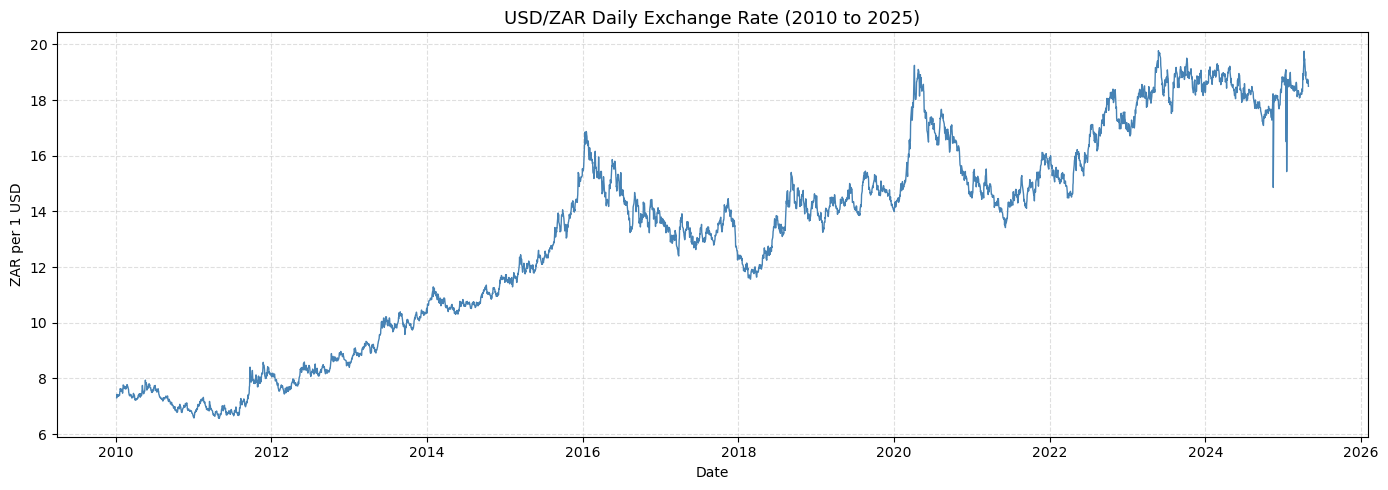

Saved: chart_01_usdzar_price.png


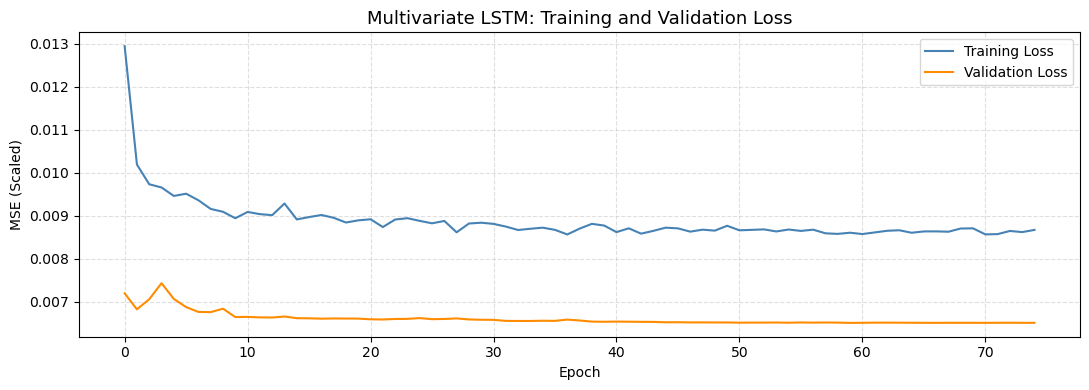

Saved: chart_02_training_loss.png


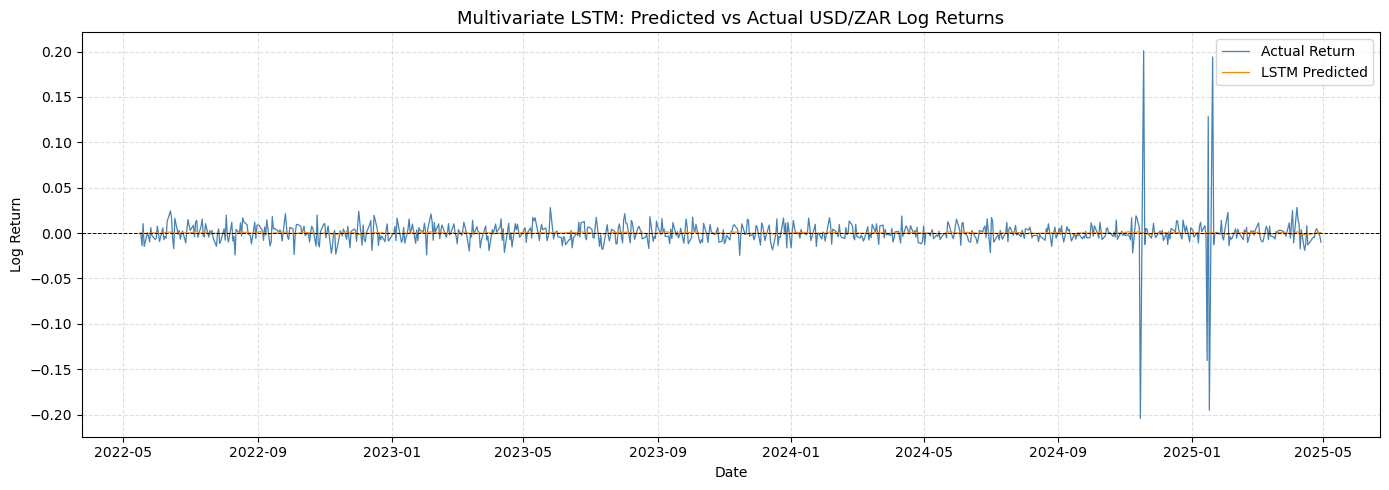

Saved: chart_03_lstm_predictions.png


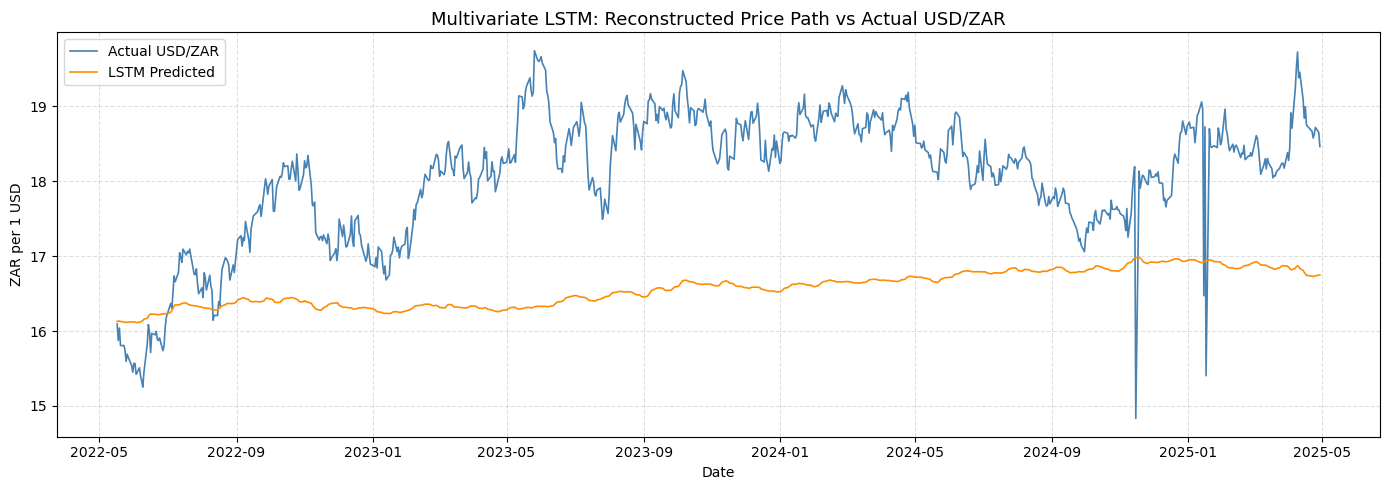

Saved: chart_04_reconstructed_price.png


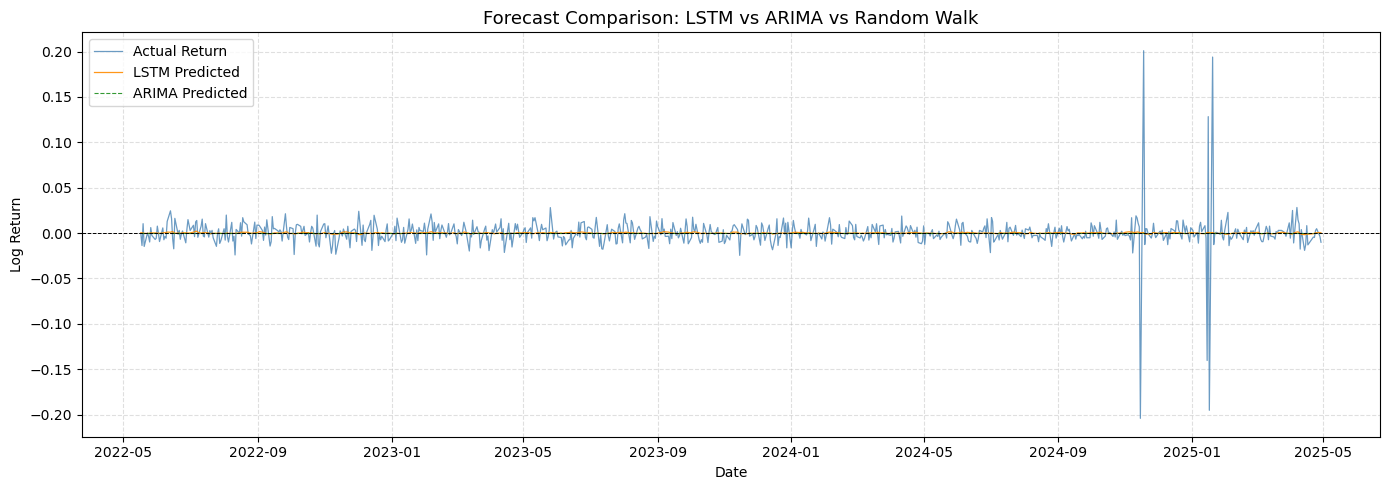

Saved: chart_05_model_comparison.png


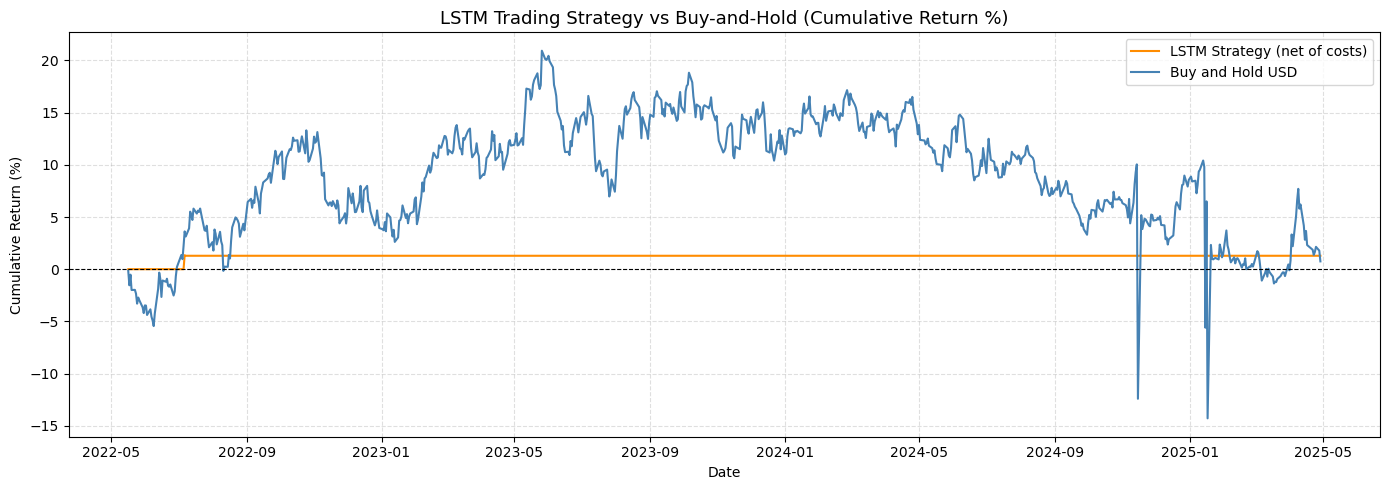

Saved: chart_06_trading_strategy.png


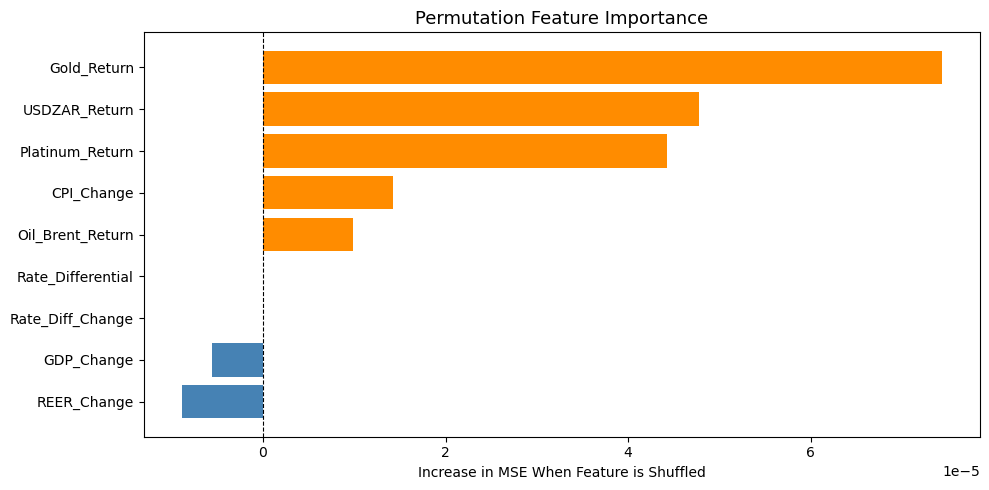

Saved: chart_07_feature_importance.png

All outputs saved to the 'project_outputs' folder.
These files can be used directly in your report and presentation.

Project complete.


In [25]:
# ── Saving all key results and charts to disk for use in the report 
import os

# Create an output folder if it does not already exist
output_dir = "project_outputs"
os.makedirs(output_dir, exist_ok=True)
# os.makedirs creates the folder; exist_ok=True prevents an error if it already exists

# ── Saving the results summary table as a CSV 
results_table = pd.DataFrame({
    "Metric"            : ["RMSE", "MAE", "Directional Accuracy (%)"],
    "LSTM_Multivariate" : [round(lstm_rmse, 6), round(lstm_mae, 6), round(lstm_dir, 2)],
    "ARIMA"             : [round(arima_rmse_a, 6), round(arima_mae_a, 6), round(arima_dir_a, 2)],
    "Random_Walk"       : [round(rw_rmse_a, 6), round(rw_mae_a, 6), round(rw_dir_a, 2)],
})
results_table.to_csv(f"{output_dir}/model_comparison.csv", index=False)
print("Saved: model_comparison.csv")

# ── Saving the feature importance table as a CSV 
importance_df.to_csv(f"{output_dir}/feature_importance.csv", index=False)
print("Saved: feature_importance.csv")

# ── Saving the master dataset as a CSV 
model_df.to_csv(f"{output_dir}/model_dataset.csv")
print("Saved: model_dataset.csv")

# ── Regenerating and save all key charts as PNG files 

# Chart 1: Full USD/ZAR price series
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["USDZAR"], color="steelblue", linewidth=1.0)
plt.title("USD/ZAR Daily Exchange Rate (2010 to 2025)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("ZAR per 1 USD")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{output_dir}/chart_01_usdzar_price.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_01_usdzar_price.png")

# Chart 2: Training and validation loss
plt.figure(figsize=(11, 4))
plt.plot(history.history["loss"],     color="steelblue",  linewidth=1.5, label="Training Loss")
plt.plot(history.history["val_loss"], color="darkorange", linewidth=1.5, label="Validation Loss")
plt.title("Multivariate LSTM: Training and Validation Loss", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("MSE (Scaled)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{output_dir}/chart_02_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_02_training_loss.png")

# Chart 3: LSTM predicted vs actual returns
plt.figure(figsize=(14, 5))
plt.plot(test_dates_final, y_test_final,    color="steelblue",  linewidth=0.9, label="Actual Return")
plt.plot(test_dates_final, lstm_preds_final, color="darkorange", linewidth=0.9, label="LSTM Predicted")
plt.axhline(0, color="black", linewidth=0.7, linestyle="--")
plt.title("Multivariate LSTM: Predicted vs Actual USD/ZAR Log Returns", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{output_dir}/chart_03_lstm_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_03_lstm_predictions.png")

# Chart 4: Reconstructed price path
plt.figure(figsize=(14, 5))
plt.plot(test_dates_final, actual_prices_reconstructed,    color="steelblue",  linewidth=1.2, label="Actual USD/ZAR")
plt.plot(test_dates_final, predicted_prices_reconstructed, color="darkorange", linewidth=1.2, label="LSTM Predicted")
plt.title("Multivariate LSTM: Reconstructed Price Path vs Actual USD/ZAR", fontsize=13)
plt.xlabel("Date")
plt.ylabel("ZAR per 1 USD")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{output_dir}/chart_04_reconstructed_price.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_04_reconstructed_price.png")

# Chart 5: Three model comparison
plt.figure(figsize=(14, 5))
plt.plot(test_dates_final, y_test_final,    color="steelblue",  linewidth=0.9, label="Actual Return",  alpha=0.8)
plt.plot(test_dates_final, lstm_preds_final, color="darkorange", linewidth=0.9, label="LSTM Predicted", alpha=0.9)
plt.plot(test_dates_final, arima_aligned,   color="green",      linewidth=0.8, linestyle="--", label="ARIMA Predicted", alpha=0.8)
plt.axhline(0, color="black", linewidth=0.7, linestyle="--")
plt.title("Forecast Comparison: LSTM vs ARIMA vs Random Walk", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{output_dir}/chart_05_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_05_model_comparison.png")

# Chart 6: Trading strategy cumulative returns
plt.figure(figsize=(14, 5))
plt.plot(test_dates_final, cumulative_strategy * 100, color="darkorange", linewidth=1.5, label="LSTM Strategy (net of costs)")
plt.plot(test_dates_final, cumulative_buy_hold * 100, color="steelblue",  linewidth=1.5, label="Buy and Hold USD")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("LSTM Trading Strategy vs Buy-and-Hold (Cumulative Return %)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"{output_dir}/chart_06_trading_strategy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_06_trading_strategy.png")

# Chart 7: Feature importance
plt.figure(figsize=(10, 5))
colors_bar = ["darkorange" if v > 0 else "steelblue" for v in importance_df["Importance"]]
plt.barh(importance_df["Feature"], importance_df["Importance"], color=colors_bar)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Permutation Feature Importance", fontsize=13)
plt.xlabel("Increase in MSE When Feature is Shuffled")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{output_dir}/chart_07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_07_feature_importance.png")

# ── Final confirmation 
print(f"\nAll outputs saved to the '{output_dir}' folder.")
print("These files can be used directly in your report and presentation.")
print("\nProject complete.")